In [36]:
# ============================================================
# CELL 1: SCATS DATASET SETUP AND FILE DISCOVERY
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Define the folder containing the raw SCATS datasets
# ------------------------------------------------------------

SCATS_FOLDER = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After"
)

print("SCATS folder:")
print(SCATS_FOLDER)

print("\nFolder exists:", SCATS_FOLDER.exists())


# ------------------------------------------------------------
# 2. Search for SCATS traffic-volume datasets from 2018–2024
# ------------------------------------------------------------

years = range(2018, 2025)

scats_files = {}

for year in years:

    pattern = f"traffic_signal_volume_data_{year}*"

    matches = list(SCATS_FOLDER.glob(pattern))

    scats_files[year] = matches


# ------------------------------------------------------------
# 3. Display what Python found
# ------------------------------------------------------------

print("\nSCATS dataset discovery")
print("-" * 70)

for year, matches in scats_files.items():

    if len(matches) == 0:
        print(f"{year}: NOT FOUND")

    else:
        print(f"{year}:")

        for file_path in matches:
            print(f"   {file_path.name}")

print("-" * 70)

SCATS folder:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After

Folder exists: True

SCATS dataset discovery
----------------------------------------------------------------------
2018:
   traffic_signal_volume_data_2018
2019:
   traffic_signal_volume_data_2019
2020:
   traffic_signal_volume_data_2020
2021:
   traffic_signal_volume_data_2021
2022:
   traffic_signal_volume_data_2022
2023:
   traffic_signal_volume_data_2023
2024:
   traffic_signal_volume_data_2024
----------------------------------------------------------------------


In [37]:
# ============================================================
# CELL 2: SCATS FILE TYPE, SIZE AND STRUCTURE INSPECTION
# ============================================================

from pathlib import Path
import os


print("=" * 75)
print("SCATS DATASET - FILE STRUCTURE INSPECTION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Inspect every yearly dataset
# ------------------------------------------------------------

scats_file_info = []

for year, matches in scats_files.items():

    if len(matches) == 0:
        continue

    for path in matches:

        path = Path(path)

        is_file = path.is_file()
        is_directory = path.is_dir()

        size_bytes = path.stat().st_size if is_file else None

        if size_bytes is not None:
            size_gb = size_bytes / (1024 ** 3)
        else:
            size_gb = None

        scats_file_info.append({
            "Year": year,
            "Name": path.name,
            "Path": str(path),
            "Is_File": is_file,
            "Is_Directory": is_directory,
            "Suffix": path.suffix,
            "Size_GB": round(size_gb, 3) if size_gb is not None else None
        })


file_info_df = pd.DataFrame(scats_file_info)


print("\nFILE / DIRECTORY SUMMARY")
print("-" * 75)
print(file_info_df.to_string(index=False))


# ------------------------------------------------------------
# 2. If datasets are directories, inspect their contents
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DIRECTORY CONTENT CHECK")
print("=" * 75)

for year, matches in scats_files.items():

    for path in matches:

        path = Path(path)

        if path.is_dir():

            print(f"\n{year} directory:")
            print(path)

            contents = list(path.iterdir())

            print("Number of items:", len(contents))

            print("\nFirst 20 items:")

            for item in contents[:20]:
                print(
                    "  ",
                    item.name,
                    "| Directory:" if item.is_dir() else "| File:",
                    item.is_dir()
                )


# ------------------------------------------------------------
# 3. If datasets are files with no extension,
#    inspect the first few raw bytes
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RAW FILE SIGNATURE CHECK")
print("=" * 75)

for year, matches in scats_files.items():

    for path in matches:

        path = Path(path)

        if path.is_file():

            print(f"\n{year}: {path.name}")

            try:
                with open(path, "rb") as f:
                    signature = f.read(100)

                print("First 100 bytes:")
                print(signature)

            except Exception as e:
                print("Could not inspect file:", e)


print("\n" + "=" * 75)
print("CELL 2 COMPLETED")
print("=" * 75)

SCATS DATASET - FILE STRUCTURE INSPECTION

FILE / DIRECTORY SUMMARY
---------------------------------------------------------------------------
 Year                            Name                                                                                 Path  Is_File  Is_Directory Suffix Size_GB
 2018 traffic_signal_volume_data_2018 C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018    False          True           None
 2019 traffic_signal_volume_data_2019 C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2019    False          True           None
 2020 traffic_signal_volume_data_2020 C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2020    False          True           None
 2021 traffic_signal_volume_data_2021 C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2021    False          True           None
 2022 traffic_signal_volume_data_2022 C:\Users\LENO

In [38]:
# ============================================================
# CELL 3: SCATS SCHEMA AND SAMPLE DATA INSPECTION
# ============================================================

from pathlib import Path
import zipfile
import pandas as pd
import os


print("=" * 75)
print("SCATS DATASET - SCHEMA AND SAMPLE INSPECTION")
print("=" * 75)


base_folder = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After"
)


# ------------------------------------------------------------
# 1. Select representative files
# ------------------------------------------------------------

sample_paths = {
    2018: base_folder / "traffic_signal_volume_data_2018" / "VSDATA_201801.zip",
    2019: base_folder / "traffic_signal_volume_data_2019",
    2020: base_folder / "traffic_signal_volume_data_2020" / "VSDATA_202001.zip",
    2021: base_folder / "traffic_signal_volume_data_2021" / "VSDATA_202101.zip",
    2022: base_folder / "traffic_signal_volume_data_2022" / "VSDATA_202201.zip",
    2023: base_folder / "traffic_signal_volume_data_2023" / "VSDATA_202301.zip",
    2024: base_folder / "traffic_signal_volume_data_2024" / "traffic_signal_volume_data_january_2024.zip"
}


# ------------------------------------------------------------
# 2. Function to inspect ZIP without extracting everything
# ------------------------------------------------------------

def inspect_zip_sample(zip_path, year, sample_rows=10):

    print("\n" + "=" * 75)
    print(f"{year} ZIP INSPECTION")
    print("=" * 75)

    print("ZIP path:")
    print(zip_path)

    if not zip_path.exists():
        print("File not found.")
        return None

    try:
        with zipfile.ZipFile(zip_path, "r") as z:

            members = z.namelist()

            print("\nFiles inside ZIP:", len(members))

            print("\nFirst 20 ZIP members:")
            for name in members[:20]:
                print("  ", name)

            csv_members = [
                name for name in members
                if name.lower().endswith(".csv")
            ]

            print("\nCSV files inside ZIP:", len(csv_members))

            if len(csv_members) == 0:
                print("No CSV files found.")
                return None

            sample_member = csv_members[0]

            print("\nSample CSV selected:")
            print(sample_member)

            # Read only a small sample directly from ZIP
            with z.open(sample_member) as f:

                sample_df = pd.read_csv(
                    f,
                    nrows=sample_rows,
                    low_memory=False
                )

            print("\nColumns:")
            print(sample_df.columns.tolist())

            print("\nNumber of columns:")
            print(len(sample_df.columns))

            print("\nSample rows:")
            print(sample_df.to_string(index=False))

            print("\nSample data types:")
            print(sample_df.dtypes)

            return sample_df

    except Exception as e:
        print("\nError while inspecting ZIP:")
        print(type(e).__name__, "-", e)

        return None


# ------------------------------------------------------------
# 3. Function to inspect extracted daily CSV files
# ------------------------------------------------------------

def inspect_csv_folder(folder_path, year, sample_rows=10):

    print("\n" + "=" * 75)
    print(f"{year} EXTRACTED CSV INSPECTION")
    print("=" * 75)

    print("Folder:")
    print(folder_path)

    if not folder_path.exists():
        print("Folder not found.")
        return None

    csv_files = sorted(
        folder_path.glob("*.csv")
    )

    print("\nCSV files discovered:", len(csv_files))

    if len(csv_files) == 0:
        print("No CSV files found.")
        return None

    sample_file = csv_files[0]

    print("\nSample CSV selected:")
    print(sample_file.name)

    try:

        sample_df = pd.read_csv(
            sample_file,
            nrows=sample_rows,
            low_memory=False
        )

        print("\nColumns:")
        print(sample_df.columns.tolist())

        print("\nNumber of columns:")
        print(len(sample_df.columns))

        print("\nSample rows:")
        print(sample_df.to_string(index=False))

        print("\nSample data types:")
        print(sample_df.dtypes)

        return sample_df

    except Exception as e:

        print("\nError while reading CSV:")
        print(type(e).__name__, "-", e)

        return None


# ------------------------------------------------------------
# 4. Inspect representative files from every year
# ------------------------------------------------------------

scats_schema_samples = {}


for year, path in sample_paths.items():

    if year == 2019:

        df_sample = inspect_csv_folder(
            path,
            year,
            sample_rows=10
        )

    else:

        df_sample = inspect_zip_sample(
            path,
            year,
            sample_rows=10
        )

    scats_schema_samples[year] = df_sample


# ------------------------------------------------------------
# 5. Compare schemas across years
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SCHEMA COMPARISON ACROSS YEARS")
print("=" * 75)


schema_summary = []

for year, df in scats_schema_samples.items():

    if df is not None:

        schema_summary.append({
            "Year": year,
            "Column_Count": len(df.columns),
            "Columns": " | ".join(df.columns.astype(str))
        })


schema_summary_df = pd.DataFrame(schema_summary)

print(
    schema_summary_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 6. Check whether column structures are identical
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("COLUMN CONSISTENCY CHECK")
print("=" * 75)


valid_samples = {
    year: df
    for year, df in scats_schema_samples.items()
    if df is not None
}


if len(valid_samples) > 1:

    reference_year = sorted(valid_samples.keys())[0]

    reference_columns = list(
        valid_samples[reference_year].columns
    )

    print("Reference year:", reference_year)

    for year, df in valid_samples.items():

        current_columns = list(df.columns)

        same_schema = (
            current_columns == reference_columns
        )

        print(
            f"{year}:",
            "Same column structure"
            if same_schema
            else "Different column structure"
        )

        if not same_schema:

            missing_from_year = [
                col
                for col in reference_columns
                if col not in current_columns
            ]

            extra_in_year = [
                col
                for col in current_columns
                if col not in reference_columns
            ]

            print(
                "   Missing compared with reference:",
                missing_from_year
            )

            print(
                "   Additional columns:",
                extra_in_year
            )


print("\n" + "=" * 75)
print("CELL 3 COMPLETED")
print("=" * 75)

SCATS DATASET - SCHEMA AND SAMPLE INSPECTION

2018 ZIP INSPECTION
ZIP path:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018\VSDATA_201801.zip

Files inside ZIP: 31

First 20 ZIP members:
   VSDATA_20180101.csv
   VSDATA_20180102.csv
   VSDATA_20180103.csv
   VSDATA_20180104.csv
   VSDATA_20180105.csv
   VSDATA_20180106.csv
   VSDATA_20180107.csv
   VSDATA_20180108.csv
   VSDATA_20180109.csv
   VSDATA_20180110.csv
   VSDATA_20180111.csv
   VSDATA_20180112.csv
   VSDATA_20180113.csv
   VSDATA_20180114.csv
   VSDATA_20180115.csv
   VSDATA_20180116.csv
   VSDATA_20180117.csv
   VSDATA_20180118.csv
   VSDATA_20180119.csv
   VSDATA_20180121.csv

CSV files inside ZIP: 31

Sample CSV selected:
VSDATA_20180101.csv

Columns:
['NB_SCATS_SITE', 'QT_INTERVAL_COUNT', 'NB_DETECTOR', 'V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V

In [39]:
# ============================================================================
# CELL 4 - MEMORY-EFFICIENT MULTI-YEAR SCATS SAMPLE LOADING
# ============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import zipfile
import re
import gc
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("SCATS DATASET - MEMORY-EFFICIENT MULTI-YEAR SAMPLE LOADING")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. BASE DATA LOCATION
# ----------------------------------------------------------------------------

SCATS_BASE = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After"
)

YEARS = list(range(2018, 2025))

print("\nBASE DATA LOCATION")
print("-" * 75)

print("SCATS folder:")
print(SCATS_BASE)

print("\nFolder exists:", SCATS_BASE.exists())


# ----------------------------------------------------------------------------
# 2. HELPER FUNCTION - EXTRACT DATE FROM FILE NAME
# ----------------------------------------------------------------------------

def extract_date_from_name(file_name):
    """
    Attempts to identify an 8-digit YYYYMMDD date contained
    inside a SCATS CSV file name.

    Example:
        VSDATA_20180101.csv -> 2018-01-01
    """

    match = re.search(r"(20\d{6})", Path(file_name).name)

    if match:
        try:
            return pd.to_datetime(
                match.group(1),
                format="%Y%m%d"
            )
        except Exception:
            return pd.NaT

    return pd.NaT


# ----------------------------------------------------------------------------
# 3. FUNCTION FOR SELECTING ONE DAILY CSV PER MONTH
# ----------------------------------------------------------------------------

def select_monthly_sample_files(year_folder, year):
    """
    Finds approximately one daily SCATS CSV for each month.

    Handles:
        - extracted CSV files
        - monthly ZIP archives
    """

    monthly_sources = []

    # ------------------------------------------------------------------------
    # CASE A: YEAR STORED AS EXTRACTED DAILY CSV FILES
    # Example: 2019
    # ------------------------------------------------------------------------

    csv_files = sorted(
        year_folder.rglob("*.csv")
    )

    if len(csv_files) > 0:

        csv_info = []

        for csv_path in csv_files:

            date_value = extract_date_from_name(
                csv_path.name
            )

            if pd.notna(date_value):

                csv_info.append(
                    {
                        "year": year,
                        "month": date_value.month,
                        "date": date_value,
                        "storage": "CSV",
                        "container": csv_path,
                        "member": None
                    }
                )

        csv_info_df = pd.DataFrame(csv_info)

        if not csv_info_df.empty:

            # Select the first available daily file in each month
            monthly_selection = (
                csv_info_df
                .sort_values("date")
                .groupby("month", as_index=False)
                .first()
            )

            monthly_sources.extend(
                monthly_selection.to_dict("records")
            )

    # ------------------------------------------------------------------------
    # CASE B: YEAR STORED AS MONTHLY ZIP ARCHIVES
    # Examples: 2018, 2020-2024
    # ------------------------------------------------------------------------

    zip_items = sorted(
        [
            item
            for item in year_folder.iterdir()
            if zipfile.is_zipfile(item)
        ],
        key=lambda x: x.name.lower()
    )

    for zip_path in zip_items:

        try:

            with zipfile.ZipFile(zip_path, "r") as archive:

                members = sorted(
                    [
                        name
                        for name in archive.namelist()
                        if name.lower().endswith(".csv")
                    ]
                )

                if len(members) == 0:
                    continue

                member_info = []

                for member in members:

                    date_value = extract_date_from_name(
                        member
                    )

                    if pd.notna(date_value):

                        member_info.append(
                            (
                                date_value,
                                member
                            )
                        )

                if len(member_info) == 0:
                    continue

                # Earliest valid daily CSV within the ZIP
                member_info.sort(
                    key=lambda x: x[0]
                )

                selected_date, selected_member = member_info[0]

                monthly_sources.append(
                    {
                        "year": year,
                        "month": selected_date.month,
                        "date": selected_date,
                        "storage": "ZIP",
                        "container": zip_path,
                        "member": selected_member
                    }
                )

        except Exception as error:

            print(
                f"Warning: Could not inspect {zip_path.name}:",
                error
            )

    # ------------------------------------------------------------------------
    # Keep only one source for each month
    # ------------------------------------------------------------------------

    if len(monthly_sources) == 0:
        return []

    source_df = pd.DataFrame(monthly_sources)

    source_df = (
        source_df
        .sort_values(["month", "date"])
        .drop_duplicates(
            subset=["month"],
            keep="first"
        )
    )

    return source_df.to_dict("records")


# ----------------------------------------------------------------------------
# 4. DISCOVER REPRESENTATIVE MONTHLY SAMPLE FILES
# ----------------------------------------------------------------------------

sample_sources = []

for year in YEARS:

    year_folder = (
        SCATS_BASE /
        f"traffic_signal_volume_data_{year}"
    )

    if not year_folder.exists():

        print(
            f"\nWARNING: {year} folder not found."
        )

        continue

    year_sources = select_monthly_sample_files(
        year_folder,
        year
    )

    sample_sources.extend(
        year_sources
    )


sample_source_df = pd.DataFrame(
    sample_sources
)

if not sample_source_df.empty:

    sample_source_df = (
        sample_source_df
        .sort_values(
            ["year", "month"]
        )
        .reset_index(drop=True)
    )


print("\n" + "=" * 75)
print("REPRESENTATIVE SAMPLE DISCOVERY")
print("=" * 75)

print(
    "\nTotal daily sample files selected:",
    len(sample_source_df)
)

if not sample_source_df.empty:

    print("\nSample files selected per year:")
    print(
        sample_source_df
        .groupby("year")
        .size()
        .rename("Sample_Days")
        .to_string()
    )

    print("\nSelected dates:")

    display(
        sample_source_df[
            [
                "year",
                "month",
                "date",
                "storage"
            ]
        ]
    )


# ----------------------------------------------------------------------------
# 5. FUNCTION TO READ ONE SAMPLE CSV
# ----------------------------------------------------------------------------

def read_scats_sample(source_record):
    """
    Reads one selected SCATS daily CSV.

    Supports both:
        - normal CSV files
        - CSV files stored inside ZIP archives
    """

    storage = source_record["storage"]

    container = source_record["container"]

    member = source_record["member"]

    if storage == "CSV":

        df = pd.read_csv(
            container,
            low_memory=False
        )

    elif storage == "ZIP":

        with zipfile.ZipFile(
            container,
            "r"
        ) as archive:

            with archive.open(
                member
            ) as csv_file:

                df = pd.read_csv(
                    csv_file,
                    low_memory=False
                )

    else:

        raise ValueError(
            f"Unknown storage type: {storage}"
        )

    # Add provenance information
    df["SOURCE_YEAR"] = source_record["year"]

    df["SOURCE_MONTH"] = source_record["month"]

    df["SOURCE_FILE_DATE"] = source_record["date"]

    return df


# ----------------------------------------------------------------------------
# 6. LOAD REPRESENTATIVE SAMPLE
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("LOADING REPRESENTATIVE SCATS SAMPLE")
print("=" * 75)

sample_frames = []

loading_summary = []

for index, record in enumerate(
    sample_sources,
    start=1
):

    try:

        sample_df = read_scats_sample(
            record
        )

        sample_frames.append(
            sample_df
        )

        loading_summary.append(
            {
                "Year": record["year"],
                "Month": record["month"],
                "Date": record["date"],
                "Rows": len(sample_df),
                "Columns": len(sample_df.columns),
                "Status": "Loaded"
            }
        )

        print(
            f"[{index:02d}/{len(sample_sources):02d}] "
            f"{record['year']}-"
            f"{record['month']:02d} | "
            f"{len(sample_df):,} rows"
        )

    except Exception as error:

        loading_summary.append(
            {
                "Year": record["year"],
                "Month": record["month"],
                "Date": record["date"],
                "Rows": np.nan,
                "Columns": np.nan,
                "Status": f"ERROR: {error}"
            }
        )

        print(
            f"[{index:02d}/{len(sample_sources):02d}] "
            f"FAILED:",
            error
        )


# ----------------------------------------------------------------------------
# 7. COMBINE REPRESENTATIVE SAMPLE
# ----------------------------------------------------------------------------

if len(sample_frames) == 0:

    raise RuntimeError(
        "No SCATS sample files could be loaded."
    )


scats_sample = pd.concat(
    sample_frames,
    ignore_index=True
)

del sample_frames

gc.collect()


# ----------------------------------------------------------------------------
# 8. CONVERT DATE COLUMN
# ----------------------------------------------------------------------------

scats_sample[
    "QT_INTERVAL_COUNT"
] = pd.to_datetime(
    scats_sample["QT_INTERVAL_COUNT"],
    errors="coerce"
)


# ----------------------------------------------------------------------------
# 9. IDENTIFY VOLUME INTERVAL COLUMNS
# ----------------------------------------------------------------------------

volume_columns = [
    f"V{i:02d}"
    for i in range(96)
]

available_volume_columns = [
    column
    for column in volume_columns
    if column in scats_sample.columns
]


# ----------------------------------------------------------------------------
# 10. BASIC SAMPLE SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("COMBINED SAMPLE SUMMARY")
print("=" * 75)

print(
    "Rows loaded:",
    f"{len(scats_sample):,}"
)

print(
    "Columns:",
    len(scats_sample.columns)
)

print(
    "Traffic interval columns:",
    len(available_volume_columns)
)

print(
    "Years represented:",
    sorted(
        scats_sample[
            "SOURCE_YEAR"
        ].unique()
    )
)

print(
    "Unique SCATS sites:",
    scats_sample[
        "NB_SCATS_SITE"
    ].nunique()
)

print(
    "Unique detectors:",
    scats_sample[
        [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Regions represented:",
    scats_sample[
        "NM_REGION"
    ].nunique()
)

print(
    "Earliest sampled date:",
    scats_sample[
        "QT_INTERVAL_COUNT"
    ].min()
)

print(
    "Latest sampled date:",
    scats_sample[
        "QT_INTERVAL_COUNT"
    ].max()
)


# ----------------------------------------------------------------------------
# 11. MEMORY USAGE
# ----------------------------------------------------------------------------

memory_mb = (
    scats_sample
    .memory_usage(
        deep=True
    )
    .sum()
    / 1024**2
)

print(
    "\nApproximate sample memory usage:",
    f"{memory_mb:,.2f} MB"
)


# ----------------------------------------------------------------------------
# 12. YEAR-LEVEL LOADING SUMMARY
# ----------------------------------------------------------------------------

year_sample_summary = (
    scats_sample
    .groupby("SOURCE_YEAR")
    .agg(
        Sample_Rows=(
            "NB_SCATS_SITE",
            "size"
        ),
        Sample_Days=(
            "QT_INTERVAL_COUNT",
            "nunique"
        ),
        Unique_Sites=(
            "NB_SCATS_SITE",
            "nunique"
        ),
        Regions=(
            "NM_REGION",
            "nunique"
        )
    )
    .reset_index()
)


print("\n" + "=" * 75)
print("YEAR-LEVEL SAMPLE SUMMARY")
print("=" * 75)

display(
    year_sample_summary
)


# ----------------------------------------------------------------------------
# 13. SAMPLE RECORDS
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("SAMPLE RECORDS")
print("=" * 75)

display(
    scats_sample[
        [
            "SOURCE_YEAR",
            "QT_INTERVAL_COUNT",
            "NB_SCATS_SITE",
            "NB_DETECTOR",
            "NM_REGION",
            "CT_RECORDS",
            "QT_VOLUME_24HOUR",
            "CT_ALARM_24HOUR"
        ]
    ].head(15)
)


# ----------------------------------------------------------------------------
# 14. OUTPUT OBJECTS FOR NEXT CELLS
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 4 OUTPUT OBJECTS")
print("=" * 75)

print(
    "scats_sample:",
    f"{len(scats_sample):,}",
    "rows"
)

print(
    "volume_columns:",
    len(volume_columns),
    "expected 15-minute interval columns"
)

print(
    "available_volume_columns:",
    len(available_volume_columns)
)

print(
    "sample_source_df:",
    len(sample_source_df),
    "selected daily source files"
)

print(
    "year_sample_summary:",
    len(year_sample_summary),
    "year records"
)


print("\n" + "=" * 75)
print("CELL 4 SUMMARY")
print("=" * 75)

print(
    "A representative SCATS sample has been loaded without reading the "
    "entire multi-gigabyte dataset into memory."
)

print(
    "Approximately one daily file per month has been selected across "
    "2018-2024."
)

print(
    "Both ZIP-based and extracted CSV storage structures are supported."
)

print(
    "All V00-V95 traffic interval columns have been retained for "
    "data-quality analysis and later hourly aggregation."
)

print(
    "\nCell 4 memory-efficient sample loading completed."
)

SCATS DATASET - MEMORY-EFFICIENT MULTI-YEAR SAMPLE LOADING

BASE DATA LOCATION
---------------------------------------------------------------------------
SCATS folder:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After

Folder exists: True

REPRESENTATIVE SAMPLE DISCOVERY

Total daily sample files selected: 83

Sample files selected per year:
year
2018    11
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12

Selected dates:


,year,month,date,storage
0,2018,1,2018-01-01,ZIP
1,2018,2,2018-02-01,ZIP
2,2018,3,2018-03-01,ZIP
3,2018,4,2018-04-01,ZIP
4,2018,5,2018-05-01,ZIP
...,...,...,...,...
78,2024,8,2024-08-01,ZIP
79,2024,9,2024-09-01,ZIP
80,2024,10,2024-10-01,ZIP
81,2024,11,2024-11-01,ZIP



LOADING REPRESENTATIVE SCATS SAMPLE
[01/83] 2018-01 | 69,332 rows
[02/83] 2018-02 | 69,459 rows
[03/83] 2018-03 | 69,557 rows
[04/83] 2018-04 | 69,565 rows
[05/83] 2018-05 | 69,576 rows
[06/83] 2018-06 | 69,672 rows
[07/83] 2018-07 | 69,699 rows
[08/83] 2018-08 | 70,209 rows
[09/83] 2018-09 | 70,275 rows
[10/83] 2018-10 | 70,338 rows
[11/83] 2018-11 | 70,493 rows
[12/83] 2019-01 | 70,719 rows
[13/83] 2019-02 | 70,822 rows
[14/83] 2019-03 | 70,941 rows
[15/83] 2019-04 | 71,293 rows
[16/83] 2019-05 | 71,465 rows
[17/83] 2019-06 | 71,700 rows
[18/83] 2019-07 | 71,935 rows
[19/83] 2019-08 | 98,978 rows
[20/83] 2019-09 | 99,010 rows
[21/83] 2019-10 | 99,023 rows
[22/83] 2019-11 | 99,186 rows
[23/83] 2019-12 | 99,288 rows
[24/83] 2020-01 | 99,397 rows
[25/83] 2020-02 | 99,447 rows
[26/83] 2020-03 | 99,608 rows
[27/83] 2020-04 | 99,745 rows
[28/83] 2020-05 | 99,990 rows
[29/83] 2020-06 | 100,198 rows
[30/83] 2020-07 | 100,419 rows
[31/83] 2020-08 | 100,554 rows
[32/83] 2020-09 | 100,611 rows

,SOURCE_YEAR,Sample_Rows,Sample_Days,Unique_Sites,Regions
0,2018,768175,11,3977,34
1,2019,994360,12,4167,34
2,2020,1202871,12,4271,34
3,2021,1224423,6,4427,72
4,2022,1260349,0,4466,71
5,2023,1308787,0,4573,40
6,2024,1339249,0,4603,40



SAMPLE RECORDS


,SOURCE_YEAR,QT_INTERVAL_COUNT,NB_SCATS_SITE,NB_DETECTOR,NM_REGION,CT_RECORDS,QT_VOLUME_24HOUR,CT_ALARM_24HOUR
0,2018,2018-01-01,105,1,BBN,96,2749,0
1,2018,2018-01-01,105,2,BBN,96,4608,0
2,2018,2018-01-01,105,3,BBN,96,5401,0
3,2018,2018-01-01,105,4,BBN,96,349,0
4,2018,2018-01-01,105,5,BBN,96,4918,0
5,2018,2018-01-01,105,6,BBN,96,5166,0
6,2018,2018-01-01,105,7,BBN,96,3302,0
7,2018,2018-01-01,105,8,BBN,96,362,0
8,2018,2018-01-01,105,9,BBN,96,103,2
9,2018,2018-01-01,105,10,BBN,96,353,0



CELL 4 OUTPUT OBJECTS
scats_sample: 8,098,214 rows
volume_columns: 96 expected 15-minute interval columns
available_volume_columns: 96
sample_source_df: 83 selected daily source files
year_sample_summary: 7 year records

CELL 4 SUMMARY
A representative SCATS sample has been loaded without reading the entire multi-gigabyte dataset into memory.
Approximately one daily file per month has been selected across 2018-2024.
Both ZIP-based and extracted CSV storage structures are supported.
All V00-V95 traffic interval columns have been retained for data-quality analysis and later hourly aggregation.

Cell 4 memory-efficient sample loading completed.


In [40]:
# ============================================================================
# CELL 4A - SCATS CROSS-YEAR SCHEMA AND DATE FORMAT DIAGNOSTIC
# ============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import zipfile
import gc

print("=" * 75)
print("SCATS DATASET - CROSS-YEAR SCHEMA AND DATE DIAGNOSTIC")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. CHECK MONTH COVERAGE FROM CELL 4 DISCOVERY
# ----------------------------------------------------------------------------

print("\nMONTH COVERAGE BY YEAR")
print("-" * 75)

expected_months = set(range(1, 13))

month_coverage_rows = []

for year in range(2018, 2025):

    selected_months = set(
        sample_source_df.loc[
            sample_source_df["year"] == year,
            "month"
        ].astype(int)
    )

    missing_months = sorted(
        expected_months - selected_months
    )

    month_coverage_rows.append(
        {
            "Year": year,
            "Months_Selected": len(selected_months),
            "Selected_Months": sorted(selected_months),
            "Missing_Months": missing_months
        }
    )

month_coverage = pd.DataFrame(month_coverage_rows)

display(month_coverage)


# ----------------------------------------------------------------------------
# 2. HELPER - READ ONLY A SMALL NUMBER OF ROWS
# ----------------------------------------------------------------------------

def read_small_scats_extract(record, nrows=5):

    if record["storage"] == "CSV":

        return pd.read_csv(
            record["container"],
            nrows=nrows,
            low_memory=False
        )

    elif record["storage"] == "ZIP":

        with zipfile.ZipFile(
            record["container"],
            "r"
        ) as archive:

            with archive.open(
                record["member"]
            ) as csv_file:

                return pd.read_csv(
                    csv_file,
                    nrows=nrows,
                    low_memory=False
                )

    else:
        raise ValueError(
            f"Unknown storage type: {record['storage']}"
        )


# ----------------------------------------------------------------------------
# 3. SELECT ONE SOURCE FROM EACH YEAR
# ----------------------------------------------------------------------------

year_records = []

for year in range(2018, 2025):

    year_rows = sample_source_df[
        sample_source_df["year"] == year
    ]

    if len(year_rows) == 0:
        continue

    # Prefer January
    january = year_rows[
        year_rows["month"] == 1
    ]

    if len(january) > 0:
        source_row = january.iloc[0]
    else:
        source_row = year_rows.iloc[0]

    year_records.append(
        source_row.to_dict()
    )


# ----------------------------------------------------------------------------
# 4. INSPECT COLUMN STRUCTURE AND QT_INTERVAL_COUNT
# ----------------------------------------------------------------------------

schema_results = []

qt_examples = []

for record in year_records:

    year = int(record["year"])

    try:

        small_df = read_small_scats_extract(
            record,
            nrows=10
        )

        schema_results.append(
            {
                "Year": year,
                "Columns": len(small_df.columns),
                "Has_QT_INTERVAL_COUNT":
                    "QT_INTERVAL_COUNT" in small_df.columns,
                "Has_QT_VOLUME_24HOUR":
                    "QT_VOLUME_24HOUR" in small_df.columns,
                "Has_CT_RECORDS":
                    "CT_RECORDS" in small_df.columns,
                "First_Column":
                    small_df.columns[0],
                "Last_Column":
                    small_df.columns[-1]
            }
        )

        if "QT_INTERVAL_COUNT" in small_df.columns:

            values = small_df[
                "QT_INTERVAL_COUNT"
            ].head(5).tolist()

            dtype_value = str(
                small_df[
                    "QT_INTERVAL_COUNT"
                ].dtype
            )

        else:

            values = ["COLUMN NOT PRESENT"]
            dtype_value = "N/A"

        qt_examples.append(
            {
                "Year": year,
                "QT_INTERVAL_COUNT_dtype": dtype_value,
                "Example_Values": values
            }
        )

    except Exception as error:

        schema_results.append(
            {
                "Year": year,
                "Columns": np.nan,
                "Has_QT_INTERVAL_COUNT": False,
                "Has_QT_VOLUME_24HOUR": False,
                "Has_CT_RECORDS": False,
                "First_Column": "ERROR",
                "Last_Column": str(error)
            }
        )


schema_check = pd.DataFrame(
    schema_results
)

qt_format_check = pd.DataFrame(
    qt_examples
)


print("\n" + "=" * 75)
print("SCHEMA COMPARISON")
print("=" * 75)

display(schema_check)


print("\n" + "=" * 75)
print("QT_INTERVAL_COUNT FORMAT BY YEAR")
print("=" * 75)

pd.set_option(
    "display.max_colwidth",
    None
)

display(qt_format_check)


# ----------------------------------------------------------------------------
# 5. DISPLAY COMPLETE COLUMN LIST FOR EACH YEAR
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("COLUMN DIFFERENCES BY YEAR")
print("=" * 75)

year_column_sets = {}

for record in year_records:

    year = int(record["year"])

    try:

        tiny_df = read_small_scats_extract(
            record,
            nrows=1
        )

        year_column_sets[year] = list(
            tiny_df.columns
        )

        print(f"\n{year} ({len(tiny_df.columns)} columns)")
        print(tiny_df.columns.tolist())

    except Exception as error:

        print(
            f"\n{year}: ERROR - {error}"
        )


# ----------------------------------------------------------------------------
# 6. IDENTIFY SCHEMA CHANGES RELATIVE TO 2018
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("SCHEMA DIFFERENCES RELATIVE TO 2018")
print("=" * 75)

if 2018 in year_column_sets:

    base_columns = set(
        year_column_sets[2018]
    )

    difference_rows = []

    for year, columns in year_column_sets.items():

        current_columns = set(columns)

        added = sorted(
            current_columns - base_columns
        )

        removed = sorted(
            base_columns - current_columns
        )

        difference_rows.append(
            {
                "Year": year,
                "Added_Columns": added,
                "Removed_Columns": removed
            }
        )

    schema_differences = pd.DataFrame(
        difference_rows
    )

    display(schema_differences)


# ----------------------------------------------------------------------------
# 7. CHECK WHY 2018 HAS ONLY 11 MONTHS
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("2018 ZIP CONTENT CHECK")
print("=" * 75)

folder_2018 = (
    SCATS_BASE /
    "traffic_signal_volume_data_2018"
)

zip_2018 = sorted(
    folder_2018.iterdir(),
    key=lambda p: p.name
)

zip_check_rows = []

for zip_path in zip_2018:

    if not zipfile.is_zipfile(zip_path):
        continue

    try:

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as archive:

            csv_members = [
                m
                for m in archive.namelist()
                if m.lower().endswith(".csv")
            ]

            dated_members = []

            for member in csv_members:

                parsed_date = extract_date_from_name(
                    member
                )

                if pd.notna(parsed_date):
                    dated_members.append(
                        parsed_date
                    )

            zip_check_rows.append(
                {
                    "ZIP_File": zip_path.name,
                    "CSV_Files": len(csv_members),
                    "Files_With_Recognised_Date":
                        len(dated_members),
                    "Earliest_Recognised_Date":
                        min(dated_members)
                        if dated_members
                        else pd.NaT,
                    "Latest_Recognised_Date":
                        max(dated_members)
                        if dated_members
                        else pd.NaT
                }
            )

    except Exception as error:

        zip_check_rows.append(
            {
                "ZIP_File": zip_path.name,
                "CSV_Files": np.nan,
                "Files_With_Recognised_Date": np.nan,
                "Earliest_Recognised_Date": pd.NaT,
                "Latest_Recognised_Date": pd.NaT,
                "Error": str(error)
            }
        )


zip_2018_check = pd.DataFrame(
    zip_check_rows
)

display(zip_2018_check)


# ----------------------------------------------------------------------------
# 8. REMOVE GIANT CELL 4 DATAFRAME FROM MEMORY
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("MEMORY CLEAN-UP")
print("=" * 75)

if "scats_sample" in globals():

    approx_memory = (
        scats_sample
        .memory_usage(deep=True)
        .sum()
        / 1024**3
    )

    print(
        f"Deleting scats_sample "
        f"(approximately {approx_memory:.2f} GB)..."
    )

    del scats_sample

    gc.collect()

    print(
        "scats_sample removed from memory."
    )

else:

    print(
        "scats_sample is not currently in memory."
    )


# ----------------------------------------------------------------------------
# 9. SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 4A SUMMARY")
print("=" * 75)

print(
    "Cross-year SCATS schema and QT_INTERVAL_COUNT formats "
    "have been inspected using only small file extracts."
)

print(
    "The missing 2018 sample month has also been investigated."
)

print(
    "The previous ~6.9 GB combined sample has been removed "
    "from memory to keep later EDA practical."
)

print(
    "\nCell 4A diagnostic completed."
)

SCATS DATASET - CROSS-YEAR SCHEMA AND DATE DIAGNOSTIC

MONTH COVERAGE BY YEAR
---------------------------------------------------------------------------


,Year,Months_Selected,Selected_Months,Missing_Months
0,2018,11,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",[12]
1,2019,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
2,2020,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
3,2021,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
4,2022,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
5,2023,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]
6,2024,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",[]



SCHEMA COMPARISON


,Year,Columns,Has_QT_INTERVAL_COUNT,Has_QT_VOLUME_24HOUR,Has_CT_RECORDS,First_Column,Last_Column
0,2018,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR
1,2019,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR
2,2020,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR
3,2021,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR
4,2022,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR
5,2023,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR
6,2024,103,True,True,True,NB_SCATS_SITE,CT_ALARM_24HOUR



QT_INTERVAL_COUNT FORMAT BY YEAR


...


COLUMN DIFFERENCES BY YEAR

2018 (103 columns)
['NB_SCATS_SITE', 'QT_INTERVAL_COUNT', 'NB_DETECTOR', 'V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'NM_REGION', 'CT_RECORDS', 'QT_VOLUME_24HOUR', 'CT_ALARM_24HOUR']

2019 (103 columns)
['NB_SCATS_SITE', 'QT_INTERVAL_COUNT', 'NB_DETECTOR', 'V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V

,Year,Added_Columns,Removed_Columns
0,2018,[],[]
1,2019,[],[]
2,2020,[],[]
3,2021,[],[]
4,2022,[],[]
5,2023,[],[]
6,2024,[],[]



2018 ZIP CONTENT CHECK


,ZIP_File,CSV_Files,Files_With_Recognised_Date,Earliest_Recognised_Date,Latest_Recognised_Date
0,VSDATA_201801.zip,31,31,2018-01-01,2018-01-31
1,VSDATA_201802.zip,28,28,2018-02-01,2018-02-28
2,VSDATA_201803.zip,31,31,2018-03-01,2018-03-31
3,VSDATA_201804.zip,30,30,2018-04-01,2018-04-30
4,VSDATA_201805.zip,31,31,2018-05-01,2018-05-31
5,VSDATA_201806.zip,30,30,2018-06-01,2018-06-30
6,VSDATA_201807.zip,31,31,2018-07-01,2018-07-31
7,VSDATA_201808.zip,31,31,2018-08-01,2018-08-31
8,VSDATA_201809.zip,30,30,2018-09-01,2018-09-30
9,VSDATA_201810.zip,31,31,2018-10-01,2018-10-31



MEMORY CLEAN-UP
Deleting scats_sample (approximately 6.74 GB)...
scats_sample removed from memory.

CELL 4A SUMMARY
Cross-year SCATS schema and QT_INTERVAL_COUNT formats have been inspected using only small file extracts.
The missing 2018 sample month has also been investigated.
The previous ~6.9 GB combined sample has been removed from memory to keep later EDA practical.

Cell 4A diagnostic completed.


In [41]:
# Check that the Cell 4 objects are available

print("scats_sample exists:", "scats_sample" in globals())
print("volume_columns exists:", "volume_columns" in globals())

if "scats_sample" in globals():
    print("Rows:", f"{len(scats_sample):,}")
    print("Columns:", len(scats_sample.columns))
    print("Memory usage (GB):",
          round(scats_sample.memory_usage(deep=True).sum() / 1024**3, 2))

scats_sample exists: False
volume_columns exists: True


In [42]:
# ============================================================================
# CELL 5 - SCATS PREPROCESSING AND MEMORY-EFFICIENT DATA QUALITY PROFILING
# ============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import zipfile
import gc

print("=" * 75)
print("SCATS DATASET - PREPROCESSING AND DATA QUALITY PROFILING")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. REQUIRED SCATS COLUMNS
# ----------------------------------------------------------------------------

volume_columns = [
    f"V{i:02d}"
    for i in range(96)
]

required_columns = [
    "NB_SCATS_SITE",
    "QT_INTERVAL_COUNT",
    "NB_DETECTOR",
    *volume_columns,
    "NM_REGION",
    "CT_RECORDS",
    "QT_VOLUME_24HOUR",
    "CT_ALARM_24HOUR"
]

print("\nEXPECTED STRUCTURE")
print("-" * 75)

print("Required SCATS columns:", len(required_columns))
print("Expected 15-minute volume columns:", len(volume_columns))


# ----------------------------------------------------------------------------
# 2. HELPER - LOAD ONE COMPLETE DAILY SOURCE FILE
# ----------------------------------------------------------------------------

def load_scats_daily_source(record):

    """
    Loads only one daily SCATS file at a time.

    This avoids combining millions of detector records into memory.
    """

    storage = record["storage"]

    if storage == "CSV":

        df = pd.read_csv(
            record["container"],
            usecols=lambda c: c in required_columns,
            low_memory=False
        )

    elif storage == "ZIP":

        with zipfile.ZipFile(
            record["container"],
            "r"
        ) as archive:

            member = record["member"]

            with archive.open(member) as csv_file:

                df = pd.read_csv(
                    csv_file,
                    usecols=lambda c: c in required_columns,
                    low_memory=False
                )

    else:

        raise ValueError(
            f"Unsupported storage type: {storage}"
        )

    return df


# ----------------------------------------------------------------------------
# 3. SAFE CROSS-YEAR DATETIME PARSER
# ----------------------------------------------------------------------------

def parse_scats_date(series):

    """
    Handles both SCATS date representations:

    2018-2021:
    YYYY-MM-DD HH:MM:SS

    Later files may contain:
    YYYY-MM-DD HH:MM:SS.0000000
    """

    cleaned = (
        series
        .astype("string")
        .str.strip()
    )

    # First try pandas mixed-format parser
    try:

        parsed = pd.to_datetime(
            cleaned,
            format="mixed",
            errors="coerce"
        )

    except (TypeError, ValueError):

        # Compatibility fallback for older pandas versions
        parsed = pd.to_datetime(
            cleaned.str.replace(
                r"\.\d+$",
                "",
                regex=True
            ),
            errors="coerce"
        )

    return parsed


# ----------------------------------------------------------------------------
# 4. DATA QUALITY ACCUMULATORS
# ----------------------------------------------------------------------------

file_quality_rows = []

year_accumulator = {}

interval_missing_total = {
    col: 0
    for col in volume_columns
}

interval_negative_total = {
    col: 0
    for col in volume_columns
}

interval_zero_total = {
    col: 0
    for col in volume_columns
}

interval_valid_total = {
    col: 0
    for col in volume_columns
}


# ----------------------------------------------------------------------------
# 5. PROCESS REPRESENTATIVE FILES ONE AT A TIME
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("PROCESSING REPRESENTATIVE SCATS FILES")
print("=" * 75)

processed_files = 0
skipped_files = 0

for position, (_, record) in enumerate(
    sample_source_df.iterrows(),
    start=1
):

    year = int(record["year"])
    month = int(record["month"])

    try:

        daily = load_scats_daily_source(
            record
        )

        original_rows = len(daily)

        # --------------------------------------------------------------------
        # DATE CLEANING
        # --------------------------------------------------------------------

        daily["SCATS_DATE"] = parse_scats_date(
            daily["QT_INTERVAL_COUNT"]
        )

        invalid_dates = int(
            daily["SCATS_DATE"].isna().sum()
        )


        # --------------------------------------------------------------------
        # IDENTIFIER CLEANING
        # --------------------------------------------------------------------

        daily["NB_SCATS_SITE"] = pd.to_numeric(
            daily["NB_SCATS_SITE"],
            errors="coerce"
        )

        daily["NB_DETECTOR"] = pd.to_numeric(
            daily["NB_DETECTOR"],
            errors="coerce"
        )

        missing_sites = int(
            daily["NB_SCATS_SITE"].isna().sum()
        )

        missing_detectors = int(
            daily["NB_DETECTOR"].isna().sum()
        )


        # --------------------------------------------------------------------
        # REGION CLEANING
        # --------------------------------------------------------------------

        if "NM_REGION" in daily.columns:

            daily["NM_REGION"] = (
                daily["NM_REGION"]
                .astype("string")
                .str.strip()
            )

            missing_regions = int(
                daily["NM_REGION"].isna().sum()
            )

        else:

            missing_regions = original_rows


        # --------------------------------------------------------------------
        # CONVERT V00-V95 TO NUMERIC
        # --------------------------------------------------------------------

        existing_volume_columns = [
            col
            for col in volume_columns
            if col in daily.columns
        ]

        for col in existing_volume_columns:

            daily[col] = pd.to_numeric(
                daily[col],
                errors="coerce"
            )


        # --------------------------------------------------------------------
        # INTERVAL QUALITY STATISTICS
        # --------------------------------------------------------------------

        volume_data = daily[
            existing_volume_columns
        ]

        missing_interval_values = int(
            volume_data.isna().sum().sum()
        )

        negative_interval_values = int(
            volume_data.lt(0).sum().sum()
        )

        zero_interval_values = int(
            volume_data.eq(0).sum().sum()
        )

        total_interval_values = (
            len(daily)
            * len(existing_volume_columns)
        )

        valid_interval_values = (
            total_interval_values
            - missing_interval_values
        )


        # Column-level statistics
        for col in existing_volume_columns:

            interval_missing_total[col] += int(
                daily[col].isna().sum()
            )

            interval_negative_total[col] += int(
                daily[col].lt(0).sum()
            )

            interval_zero_total[col] += int(
                daily[col].eq(0).sum()
            )

            interval_valid_total[col] += int(
                daily[col].notna().sum()
            )


        # --------------------------------------------------------------------
        # DAILY TOTAL CHECK
        # --------------------------------------------------------------------

        if "QT_VOLUME_24HOUR" in daily.columns:

            daily["QT_VOLUME_24HOUR"] = pd.to_numeric(
                daily["QT_VOLUME_24HOUR"],
                errors="coerce"
            )

            calculated_daily_total = (
                volume_data
                .sum(
                    axis=1,
                    min_count=1
                )
            )

            daily_total_difference = (
                calculated_daily_total
                - daily["QT_VOLUME_24HOUR"]
            )

            matching_daily_totals = int(
                daily_total_difference
                .fillna(np.inf)
                .eq(0)
                .sum()
            )

            daily_total_mismatch = int(
                (
                    daily_total_difference
                    .notna()
                    &
                    daily_total_difference
                    .ne(0)
                ).sum()
            )

        else:

            matching_daily_totals = 0
            daily_total_mismatch = 0


        # --------------------------------------------------------------------
        # ALARM INFORMATION
        # --------------------------------------------------------------------

        if "CT_ALARM_24HOUR" in daily.columns:

            daily["CT_ALARM_24HOUR"] = pd.to_numeric(
                daily["CT_ALARM_24HOUR"],
                errors="coerce"
            )

            rows_with_alarm = int(
                daily[
                    "CT_ALARM_24HOUR"
                ].fillna(0).gt(0).sum()
            )

        else:

            rows_with_alarm = 0


        # --------------------------------------------------------------------
        # DUPLICATE DETECTOR-DATE CHECK
        # --------------------------------------------------------------------

        duplicate_detector_dates = int(
            daily.duplicated(
                subset=[
                    "SCATS_DATE",
                    "NB_SCATS_SITE",
                    "NB_DETECTOR"
                ],
                keep=False
            ).sum()
        )


        # --------------------------------------------------------------------
        # DATE RANGE
        # --------------------------------------------------------------------

        valid_date_values = daily[
            "SCATS_DATE"
        ].dropna()

        if len(valid_date_values) > 0:

            earliest_date = (
                valid_date_values.min()
            )

            latest_date = (
                valid_date_values.max()
            )

        else:

            earliest_date = pd.NaT
            latest_date = pd.NaT


        # --------------------------------------------------------------------
        # FILE-LEVEL SUMMARY
        # --------------------------------------------------------------------

        file_quality_rows.append(
            {
                "Year": year,
                "Month": month,
                "Rows": original_rows,

                "Unique_Sites":
                    daily[
                        "NB_SCATS_SITE"
                    ].nunique(
                        dropna=True
                    ),

                "Unique_Detectors":
                    daily[
                        [
                            "NB_SCATS_SITE",
                            "NB_DETECTOR"
                        ]
                    ].drop_duplicates().shape[0],

                "Regions":
                    daily[
                        "NM_REGION"
                    ].nunique(
                        dropna=True
                    )
                    if "NM_REGION" in daily.columns
                    else 0,

                "Invalid_Dates":
                    invalid_dates,

                "Missing_Site_ID":
                    missing_sites,

                "Missing_Detector_ID":
                    missing_detectors,

                "Missing_Region":
                    missing_regions,

                "Interval_Values":
                    total_interval_values,

                "Missing_Interval_Values":
                    missing_interval_values,

                "Negative_Interval_Values":
                    negative_interval_values,

                "Zero_Interval_Values":
                    zero_interval_values,

                "Rows_With_Alarm":
                    rows_with_alarm,

                "Daily_Total_Matches":
                    matching_daily_totals,

                "Daily_Total_Mismatches":
                    daily_total_mismatch,

                "Duplicate_Detector_Date_Rows":
                    duplicate_detector_dates,

                "Earliest_Date":
                    earliest_date,

                "Latest_Date":
                    latest_date
            }
        )


        # --------------------------------------------------------------------
        # YEAR ACCUMULATOR
        # --------------------------------------------------------------------

        if year not in year_accumulator:

            year_accumulator[year] = {
                "Rows": 0,
                "Interval_Values": 0,
                "Missing_Intervals": 0,
                "Negative_Intervals": 0,
                "Zero_Intervals": 0,
                "Invalid_Dates": 0,
                "Rows_With_Alarm": 0,
                "Daily_Total_Mismatches": 0
            }

        year_accumulator[year]["Rows"] += (
            original_rows
        )

        year_accumulator[year][
            "Interval_Values"
        ] += total_interval_values

        year_accumulator[year][
            "Missing_Intervals"
        ] += missing_interval_values

        year_accumulator[year][
            "Negative_Intervals"
        ] += negative_interval_values

        year_accumulator[year][
            "Zero_Intervals"
        ] += zero_interval_values

        year_accumulator[year][
            "Invalid_Dates"
        ] += invalid_dates

        year_accumulator[year][
            "Rows_With_Alarm"
        ] += rows_with_alarm

        year_accumulator[year][
            "Daily_Total_Mismatches"
        ] += daily_total_mismatch


        processed_files += 1

        print(
            f"[{position:02d}/{len(sample_source_df):02d}] "
            f"{year}-{month:02d} | "
            f"{original_rows:,} rows | "
            f"invalid dates: {invalid_dates:,} | "
            f"missing intervals: "
            f"{missing_interval_values:,}"
        )


        # --------------------------------------------------------------------
        # RELEASE DAILY DATAFRAME IMMEDIATELY
        # --------------------------------------------------------------------

        del daily
        del volume_data

        gc.collect()


    except Exception as error:

        skipped_files += 1

        print(
            f"[{position:02d}/{len(sample_source_df):02d}] "
            f"{year}-{month:02d} | "
            f"SKIPPED | {error}"
        )


# ----------------------------------------------------------------------------
# 6. FILE-LEVEL QUALITY DATAFRAME
# ----------------------------------------------------------------------------

scats_file_quality = pd.DataFrame(
    file_quality_rows
)

print("\n" + "=" * 75)
print("FILE-LEVEL DATA QUALITY SUMMARY")
print("=" * 75)

print(
    "Files processed:",
    processed_files
)

print(
    "Files skipped:",
    skipped_files
)

print(
    "Rows assessed:",
    f"{scats_file_quality['Rows'].sum():,}"
)

display(
    scats_file_quality.head(20)
)


# ----------------------------------------------------------------------------
# 7. YEAR-LEVEL QUALITY SUMMARY
# ----------------------------------------------------------------------------

year_quality_rows = []

for year, stats in sorted(
    year_accumulator.items()
):

    interval_values = stats[
        "Interval_Values"
    ]

    if interval_values > 0:

        missing_percentage = (
            stats["Missing_Intervals"]
            / interval_values
            * 100
        )

        negative_percentage = (
            stats["Negative_Intervals"]
            / interval_values
            * 100
        )

        zero_percentage = (
            stats["Zero_Intervals"]
            / interval_values
            * 100
        )

    else:

        missing_percentage = np.nan
        negative_percentage = np.nan
        zero_percentage = np.nan


    year_quality_rows.append(
        {
            "Year": year,

            "Rows":
                stats["Rows"],

            "Invalid_Dates":
                stats["Invalid_Dates"],

            "Interval_Values":
                interval_values,

            "Missing_Intervals":
                stats["Missing_Intervals"],

            "Missing_Percentage":
                round(
                    missing_percentage,
                    4
                ),

            "Negative_Intervals":
                stats["Negative_Intervals"],

            "Negative_Percentage":
                round(
                    negative_percentage,
                    4
                ),

            "Zero_Intervals":
                stats["Zero_Intervals"],

            "Zero_Percentage":
                round(
                    zero_percentage,
                    4
                ),

            "Rows_With_Alarm":
                stats["Rows_With_Alarm"],

            "Daily_Total_Mismatches":
                stats[
                    "Daily_Total_Mismatches"
                ]
        }
    )


scats_year_quality = pd.DataFrame(
    year_quality_rows
)


print("\n" + "=" * 75)
print("YEAR-LEVEL DATA QUALITY SUMMARY")
print("=" * 75)

display(
    scats_year_quality
)


# ----------------------------------------------------------------------------
# 8. INTERVAL-LEVEL QUALITY SUMMARY
# ----------------------------------------------------------------------------

interval_quality_rows = []

for interval in volume_columns:

    valid = interval_valid_total[
        interval
    ]

    missing = interval_missing_total[
        interval
    ]

    negative = interval_negative_total[
        interval
    ]

    zeros = interval_zero_total[
        interval
    ]

    total = valid + missing

    interval_quality_rows.append(
        {
            "Interval": interval,

            "Total_Values":
                total,

            "Valid_Values":
                valid,

            "Missing_Values":
                missing,

            "Missing_Percentage":
                round(
                    missing / total * 100,
                    4
                )
                if total > 0
                else np.nan,

            "Negative_Values":
                negative,

            "Zero_Values":
                zeros,

            "Zero_Percentage":
                round(
                    zeros / valid * 100,
                    4
                )
                if valid > 0
                else np.nan
        }
    )


scats_interval_quality = pd.DataFrame(
    interval_quality_rows
)


print("\n" + "=" * 75)
print("15-MINUTE INTERVAL QUALITY")
print("=" * 75)

display(
    scats_interval_quality
)


# ----------------------------------------------------------------------------
# 9. OVERALL DATA QUALITY
# ----------------------------------------------------------------------------

total_rows = int(
    scats_file_quality[
        "Rows"
    ].sum()
)

total_intervals = int(
    scats_file_quality[
        "Interval_Values"
    ].sum()
)

total_missing = int(
    scats_file_quality[
        "Missing_Interval_Values"
    ].sum()
)

total_negative = int(
    scats_file_quality[
        "Negative_Interval_Values"
    ].sum()
)

total_zero = int(
    scats_file_quality[
        "Zero_Interval_Values"
    ].sum()
)

total_invalid_dates = int(
    scats_file_quality[
        "Invalid_Dates"
    ].sum()
)

total_alarm_rows = int(
    scats_file_quality[
        "Rows_With_Alarm"
    ].sum()
)


print("\n" + "=" * 75)
print("OVERALL REPRESENTATIVE SAMPLE QUALITY")
print("=" * 75)

print(
    "Rows assessed:",
    f"{total_rows:,}"
)

print(
    "15-minute values assessed:",
    f"{total_intervals:,}"
)

print(
    "Invalid dates:",
    f"{total_invalid_dates:,}"
)

print(
    "Missing interval values:",
    f"{total_missing:,}"
)

print(
    "Missing interval percentage:",
    round(
        total_missing
        / total_intervals
        * 100,
        4
    )
    if total_intervals > 0
    else np.nan
)

print(
    "Negative interval values:",
    f"{total_negative:,}"
)

print(
    "Zero interval values:",
    f"{total_zero:,}"
)

print(
    "Rows containing alarms:",
    f"{total_alarm_rows:,}"
)


# ----------------------------------------------------------------------------
# 10. DATE COVERAGE AFTER CORRECTED PARSING
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("CORRECTED DATE COVERAGE")
print("=" * 75)

valid_earliest = (
    scats_file_quality[
        "Earliest_Date"
    ]
    .dropna()
)

valid_latest = (
    scats_file_quality[
        "Latest_Date"
    ]
    .dropna()
)

if len(valid_earliest) > 0:

    print(
        "Earliest successfully parsed date:",
        valid_earliest.min()
    )

    print(
        "Latest successfully parsed date:",
        valid_latest.max()
    )

else:

    print(
        "No valid dates were parsed."
    )


# ----------------------------------------------------------------------------
# 11. OUTPUT OBJECTS
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 5 OUTPUT OBJECTS")
print("=" * 75)

print(
    "scats_file_quality:",
    len(scats_file_quality),
    "file summaries"
)

print(
    "scats_year_quality:",
    len(scats_year_quality),
    "year summaries"
)

print(
    "scats_interval_quality:",
    len(scats_interval_quality),
    "15-minute interval summaries"
)


# ----------------------------------------------------------------------------
# 12. SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 75)
print("CELL 5 SUMMARY")
print("=" * 75)

print(
    "SCATS preprocessing and data-quality profiling "
    "completed using a memory-efficient file-by-file workflow."
)

print(
    "Cross-year date formats were normalised without "
    "combining the raw multi-gigabyte datasets."
)

print(
    "V00-V95 traffic volumes were converted to numeric "
    "and checked for missing, negative and zero values."
)

print(
    "Daily reported volume totals, alarm records, "
    "identifiers and duplicate detector-date records "
    "were also assessed."
)

print(
    "The resulting compact summary objects are ready "
    "for temporal traffic-volume EDA and hourly aggregation."
)

print(
    "\nCell 5 preprocessing and data-quality profiling completed."
)

SCATS DATASET - PREPROCESSING AND DATA QUALITY PROFILING

EXPECTED STRUCTURE
---------------------------------------------------------------------------
Required SCATS columns: 103
Expected 15-minute volume columns: 96

PROCESSING REPRESENTATIVE SCATS FILES
[01/83] 2018-01 | 69,332 rows | invalid dates: 0 | missing intervals: 0
[02/83] 2018-02 | 69,459 rows | invalid dates: 0 | missing intervals: 593
[03/83] 2018-03 | 69,557 rows | invalid dates: 0 | missing intervals: 222
[04/83] 2018-04 | 69,565 rows | invalid dates: 0 | missing intervals: 0
[05/83] 2018-05 | 69,576 rows | invalid dates: 0 | missing intervals: 266
[06/83] 2018-06 | 69,672 rows | invalid dates: 0 | missing intervals: 610
[07/83] 2018-07 | 69,699 rows | invalid dates: 0 | missing intervals: 0
[08/83] 2018-08 | 70,209 rows | invalid dates: 0 | missing intervals: 0
[09/83] 2018-09 | 70,275 rows | invalid dates: 0 | missing intervals: 0
[10/83] 2018-10 | 70,338 rows | invalid dates: 0 | missing intervals: 3,496
[11/83] 20

,Year,Month,Rows,Unique_Sites,Unique_Detectors,Regions,Invalid_Dates,Missing_Site_ID,Missing_Detector_ID,Missing_Region,Interval_Values,Missing_Interval_Values,Negative_Interval_Values,Zero_Interval_Values,Rows_With_Alarm,Daily_Total_Matches,Daily_Total_Mismatches,Duplicate_Detector_Date_Rows,Earliest_Date,Latest_Date
0,2018,1,69332,3865,69332,34,0,0,0,0,6655872,0,127805,3408964,3111,66221,3111,0,2018-01-01,2018-01-01
1,2018,2,69459,3871,69459,34,0,0,0,0,6668064,593,137383,3405530,2932,66527,2932,0,2018-02-01,2018-02-01
2,2018,3,69557,3879,69557,34,0,0,0,0,6677472,222,141783,3414094,3184,66373,3184,0,2018-03-01,2018-03-01
3,2018,4,69565,3882,69565,34,0,0,0,0,6678240,0,142933,3510448,2341,67224,2341,0,2018-04-01,2018-04-01
4,2018,5,69576,3888,69576,34,0,0,0,0,6679296,266,159218,3429170,3361,66215,3361,0,2018-05-01,2018-05-01
5,2018,6,69672,3894,69672,34,0,0,0,0,6688512,610,171560,3404776,3723,65949,3723,0,2018-06-01,2018-06-01
6,2018,7,69699,3899,69699,34,0,0,0,0,6691104,0,174572,3473868,2552,67147,2552,0,2018-07-01,2018-07-01
7,2018,8,70209,3945,70205,34,0,0,0,0,6740064,0,205725,3435008,3394,66815,3394,8,2018-08-01,2018-08-01
8,2018,9,70275,3954,70271,34,0,0,0,0,6746400,0,206782,3415134,3025,67250,3025,8,2018-09-01,2018-09-01
9,2018,10,70338,3963,70334,34,0,0,0,0,6752448,3496,213233,3459945,6030,64308,6030,8,2018-10-01,2018-10-01



YEAR-LEVEL DATA QUALITY SUMMARY


,Year,Rows,Invalid_Dates,Interval_Values,Missing_Intervals,Missing_Percentage,Negative_Intervals,Negative_Percentage,Zero_Intervals,Zero_Percentage,Rows_With_Alarm,Daily_Total_Mismatches
0,2018,768175,0,73744800,8067,0.0109,1877984,2.5466,37770164,51.2174,37324,37324
1,2019,994360,0,95458560,3654,0.0038,2521679,2.6416,54235253,56.8155,47181,47181
2,2020,1202871,0,115475616,8060,0.0070,3350343,2.9013,73093158,63.2975,58985,58985
3,2021,1224423,0,117544608,15888,0.0135,4009386,3.4109,73035305,62.1341,41580,64485
4,2022,1260349,0,120993504,0,0.0000,4421273,3.6541,74714023,61.7504,70505,75925
5,2023,1308787,0,125643552,0,0.0000,5348494,4.2569,77511680,61.6917,71349,71330
6,2024,1339249,0,128567904,0,0.0000,4557014,3.5444,80238208,62.4092,70923,70912



15-MINUTE INTERVAL QUALITY


,Interval,Total_Values,Valid_Values,Missing_Values,Missing_Percentage,Negative_Values,Zero_Values,Zero_Percentage
0,V00,8098214,8097926,288,0.0036,269502,5198483,64.1952
1,V01,8098214,8097926,288,0.0036,269592,5258347,64.9345
2,V02,8098214,8097926,288,0.0036,269182,5331983,65.8438
3,V03,8098214,8097926,288,0.0036,269331,5413327,66.8483
4,V04,8098214,8097926,288,0.0036,270999,5484055,67.7217
...,...,...,...,...,...,...,...,...
91,V91,8098214,8097885,329,0.0041,271240,4983556,61.5415
92,V92,8098214,8097885,329,0.0041,270928,5009248,61.8587
93,V93,8098214,8097885,329,0.0041,276097,5063074,62.5234
94,V94,8098214,8097885,329,0.0041,270393,5114439,63.1577



OVERALL REPRESENTATIVE SAMPLE QUALITY
Rows assessed: 8,098,214
15-minute values assessed: 777,428,544
Invalid dates: 0
Missing interval values: 35,669
Missing interval percentage: 0.0046
Negative interval values: 26,086,173
Zero interval values: 470,597,791
Rows containing alarms: 397,847

CORRECTED DATE COVERAGE
Earliest successfully parsed date: 2018-01-01 00:00:00
Latest successfully parsed date: 2024-12-01 00:00:00

CELL 5 OUTPUT OBJECTS
scats_file_quality: 83 file summaries
scats_year_quality: 7 year summaries
scats_interval_quality: 96 15-minute interval summaries

CELL 5 SUMMARY
SCATS preprocessing and data-quality profiling completed using a memory-efficient file-by-file workflow.
Cross-year date formats were normalised without combining the raw multi-gigabyte datasets.
V00-V95 traffic volumes were converted to numeric and checked for missing, negative and zero values.
Daily reported volume totals, alarm records, identifiers and duplicate detector-date records were also assess

In [45]:
print("sample_source_df exists:", "sample_source_df" in globals())

if "sample_source_df" in globals():
    print("Selected source files:", len(sample_source_df))
    print(sample_source_df.head())

sample_source_df exists: True
Selected source files: 83
   year  month       date storage  \
0  2018      1 2018-01-01     ZIP   
1  2018      2 2018-02-01     ZIP   
2  2018      3 2018-03-01     ZIP   
3  2018      4 2018-04-01     ZIP   
4  2018      5 2018-05-01     ZIP   

                                                                                                container  \
0  C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018\VSDATA_201801.zip   
1  C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018\VSDATA_201802.zip   
2  C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018\VSDATA_201803.zip   
3  C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018\VSDATA_201804.zip   
4  C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\After\traffic_signal_volume_data_2018\VSDATA_201805.zip   

                member  
0  VSDATA_20180101.csv  
1  VSDATA_201802

In [47]:
# ============================================================================
# CELL 6 - MEMORY-EFFICIENT SCATS HOURLY TRAFFIC VOLUME AGGREGATION
# ============================================================================
#
# Purpose:
#   Convert the SCATS 15-minute traffic volume observations (V00-V95)
#   into hourly traffic volumes without loading the complete 8+ million
#   row sample into memory at the same time.
#
# Data Engineering objective:
#   Build an hourly traffic-volume dataset suitable for later integration,
#   analysis and performant serving.
#
# Important:
#   This cell uses sample_source_df created in Cell 4.
#   It does NOT require scats_sample to remain in memory.
# ============================================================================

import pandas as pd
import numpy as np
import zipfile
import gc
from pathlib import Path

print("=" * 75)
print("SCATS DATASET - MEMORY-EFFICIENT HOURLY TRAFFIC AGGREGATION")
print("=" * 75)


# ============================================================================
# 1. INPUT VALIDATION
# ============================================================================

print("\nINPUT VALIDATION")
print("-" * 75)

if "sample_source_df" not in globals():
    raise NameError(
        "sample_source_df is not available. "
        "Please run Cell 4 sample discovery first."
    )

print("sample_source_df available:", True)
print("Selected daily source files:", len(sample_source_df))


# Expected SCATS 15-minute traffic volume columns
expected_volume_columns = [
    f"V{i:02d}" for i in range(96)
]

print("Expected 15-minute interval columns:", len(expected_volume_columns))


# ============================================================================
# 2. HOURLY INTERVAL DEFINITION
# ============================================================================

# Each hour consists of four 15-minute SCATS intervals.
#
# Example:
# Hour 00 = V00 + V01 + V02 + V03
# Hour 01 = V04 + V05 + V06 + V07
# ...
# Hour 23 = V92 + V93 + V94 + V95

hourly_interval_map = {
    hour: [
        f"V{i:02d}"
        for i in range(hour * 4, hour * 4 + 4)
    ]
    for hour in range(24)
}

print("\n" + "=" * 75)
print("HOURLY INTERVAL STRUCTURE")
print("=" * 75)

for hour in range(24):
    print(
        f"Hour {hour:02d}:00 -> "
        + ", ".join(hourly_interval_map[hour])
    )


# ============================================================================
# 3. FUNCTION TO READ ONE DAILY SOURCE
# ============================================================================

def read_scats_daily_source(source_row):
    """
    Reads one SCATS daily file from either:
      1. a ZIP archive, or
      2. an extracted CSV file.

    Only required columns are retained where possible.
    """

    storage = str(source_row["storage"]).upper()

    container_path = Path(
        str(source_row["container"])
    )

    member = source_row.get("member", None)

    # Columns useful for the hourly pipeline
    desired_columns = [
        "QT_INTERVAL_COUNT",
        "NB_SCATS_SITE",
        "NB_DETECTOR",
        "NM_REGION",
        "CT_RECORDS",
        "QT_VOLUME_24HOUR",
        "CT_ALARM_24HOUR"
    ] + expected_volume_columns

    # ------------------------------------------------------------------------
    # ZIP SOURCE
    # ------------------------------------------------------------------------

    if storage == "ZIP":

        with zipfile.ZipFile(container_path, "r") as archive:

            # Use the member recorded in sample_source_df
            if pd.notna(member):
                csv_member = str(member)

            else:
                csv_members = [
                    name
                    for name in archive.namelist()
                    if name.lower().endswith(".csv")
                ]

                if not csv_members:
                    raise FileNotFoundError(
                        f"No CSV found inside {container_path}"
                    )

                csv_member = csv_members[0]

            # Read header first so changing schemas do not cause failure
            with archive.open(csv_member) as file_object:

                header = pd.read_csv(
                    file_object,
                    nrows=0
                )

            available_columns = [
                col
                for col in desired_columns
                if col in header.columns
            ]

            with archive.open(csv_member) as file_object:

                daily_df = pd.read_csv(
                    file_object,
                    usecols=available_columns,
                    low_memory=False
                )

    # ------------------------------------------------------------------------
    # CSV SOURCE
    # ------------------------------------------------------------------------

    else:

        csv_path = container_path

        # Some extracted structures may store the actual CSV below
        # a directory path.
        if csv_path.is_dir():

            csv_candidates = list(
                csv_path.rglob("*.csv")
            )

            if len(csv_candidates) == 0:
                raise FileNotFoundError(
                    f"No CSV file found in {csv_path}"
                )

            csv_path = csv_candidates[0]

        header = pd.read_csv(
            csv_path,
            nrows=0
        )

        available_columns = [
            col
            for col in desired_columns
            if col in header.columns
        ]

        daily_df = pd.read_csv(
            csv_path,
            usecols=available_columns,
            low_memory=False
        )

    return daily_df


# ============================================================================
# 4. PROCESS EACH DAILY SAMPLE
# ============================================================================

print("\n" + "=" * 75)
print("PROCESSING DAILY SCATS SAMPLES")
print("=" * 75)

hourly_results = []

processing_summary = []

total_sources = len(sample_source_df)


for position, (_, source_row) in enumerate(
    sample_source_df.iterrows(),
    start=1
):

    source_year = int(source_row["year"])
    source_month = int(source_row["month"])

    # IMPORTANT:
    # Use the date discovered from the filename / archive rather than relying
    # only on QT_INTERVAL_COUNT because schema/date behaviour differs across
    # SCATS years.
    source_date = pd.to_datetime(
        source_row["date"],
        errors="coerce"
    )

    try:

        # --------------------------------------------------------------------
        # Read only one daily source
        # --------------------------------------------------------------------

        daily_df = read_scats_daily_source(
            source_row
        )

        original_rows = len(daily_df)

        # --------------------------------------------------------------------
        # Check available traffic intervals
        # --------------------------------------------------------------------

        available_intervals = [
            col
            for col in expected_volume_columns
            if col in daily_df.columns
        ]

        missing_intervals = [
            col
            for col in expected_volume_columns
            if col not in daily_df.columns
        ]

        if len(available_intervals) == 0:

            print(
                f"[{position:02d}/{total_sources}] "
                f"{source_year}-{source_month:02d} | "
                "SKIPPED - no V00-V95 columns"
            )

            continue

        # --------------------------------------------------------------------
        # Convert volume values to numeric
        # --------------------------------------------------------------------

        for col in available_intervals:

            daily_df[col] = pd.to_numeric(
                daily_df[col],
                errors="coerce"
            )

        # Site / detector conversion
        for col in [
            "NB_SCATS_SITE",
            "NB_DETECTOR"
        ]:

            if col in daily_df.columns:

                daily_df[col] = pd.to_numeric(
                    daily_df[col],
                    errors="coerce"
                )

        # --------------------------------------------------------------------
        # Create 24 hourly traffic-volume columns
        # --------------------------------------------------------------------

        hourly_columns_created = []

        for hour in range(24):

            interval_cols = [
                col
                for col in hourly_interval_map[hour]
                if col in daily_df.columns
            ]

            hourly_col = (
                f"HOUR_{hour:02d}_VOLUME"
            )

            if len(interval_cols) == 4:

                daily_df[hourly_col] = (
                    daily_df[interval_cols]
                    .sum(
                        axis=1,
                        min_count=1
                    )
                )

            else:

                # If a schema is missing one or more intervals,
                # still calculate from available intervals.
                daily_df[hourly_col] = (
                    daily_df[interval_cols]
                    .sum(
                        axis=1,
                        min_count=1
                    )
                )

            hourly_columns_created.append(
                hourly_col
            )

        # --------------------------------------------------------------------
        # Convert wide hourly values to long format
        # --------------------------------------------------------------------

        identifier_columns = [
            col
            for col in [
                "NB_SCATS_SITE",
                "NB_DETECTOR",
                "NM_REGION"
            ]
            if col in daily_df.columns
        ]

        daily_hourly_long = daily_df[
            identifier_columns
            + hourly_columns_created
        ].melt(
            id_vars=identifier_columns,
            value_vars=hourly_columns_created,
            var_name="Hour_Label",
            value_name="Detector_Hourly_Volume"
        )

        # Extract hour number
        daily_hourly_long["Hour"] = (
            daily_hourly_long[
                "Hour_Label"
            ]
            .str.extract(r"HOUR_(\d{2})")[0]
            .astype("int16")
        )

        daily_hourly_long.drop(
            columns="Hour_Label",
            inplace=True
        )

        # --------------------------------------------------------------------
        # Attach reliable source date
        # --------------------------------------------------------------------

        daily_hourly_long[
            "Date"
        ] = source_date

        daily_hourly_long[
            "SOURCE_YEAR"
        ] = source_year

        daily_hourly_long[
            "SOURCE_MONTH"
        ] = source_month

        # Complete hourly timestamp
        daily_hourly_long[
            "Hourly_Timestamp"
        ] = (
            daily_hourly_long["Date"]
            + pd.to_timedelta(
                daily_hourly_long["Hour"],
                unit="h"
            )
        )

        # --------------------------------------------------------------------
        # Remove impossible / missing traffic values
        # --------------------------------------------------------------------

        daily_hourly_long[
            "Detector_Hourly_Volume"
        ] = pd.to_numeric(
            daily_hourly_long[
                "Detector_Hourly_Volume"
            ],
            errors="coerce"
        )

        negative_volume_count = (
            daily_hourly_long[
                "Detector_Hourly_Volume"
            ] < 0
        ).sum()

        daily_hourly_long.loc[
            daily_hourly_long[
                "Detector_Hourly_Volume"
            ] < 0,
            "Detector_Hourly_Volume"
        ] = np.nan

        # --------------------------------------------------------------------
        # AGGREGATE DETECTORS TO SCATS SITE + HOUR
        # --------------------------------------------------------------------

        grouping_columns = [
            "SOURCE_YEAR",
            "SOURCE_MONTH",
            "Date",
            "Hourly_Timestamp",
            "Hour",
            "NB_SCATS_SITE"
        ]

        if "NM_REGION" in daily_hourly_long.columns:
            grouping_columns.append(
                "NM_REGION"
            )

        site_hourly = (
            daily_hourly_long
            .groupby(
                grouping_columns,
                dropna=False,
                as_index=False
            )
            .agg(
                Hourly_Traffic_Volume=(
                    "Detector_Hourly_Volume",
                    "sum"
                ),
                Active_Detectors=(
                    "NB_DETECTOR",
                    "nunique"
                ),
                Mean_Detector_Hourly_Volume=(
                    "Detector_Hourly_Volume",
                    "mean"
                ),
                Median_Detector_Hourly_Volume=(
                    "Detector_Hourly_Volume",
                    "median"
                ),
                Maximum_Detector_Hourly_Volume=(
                    "Detector_Hourly_Volume",
                    "max"
                )
            )
        )

        # --------------------------------------------------------------------
        # DATA QUALITY FIELD
        # --------------------------------------------------------------------

        site_hourly[
            "Valid_Volume"
        ] = (
            site_hourly[
                "Hourly_Traffic_Volume"
            ].notna()
        )

        hourly_results.append(
            site_hourly
        )

        processing_summary.append({
            "SOURCE_YEAR":
                source_year,

            "SOURCE_MONTH":
                source_month,

            "SOURCE_DATE":
                source_date,

            "Raw_Rows":
                original_rows,

            "Intervals_Available":
                len(available_intervals),

            "Intervals_Missing":
                len(missing_intervals),

            "Negative_Hourly_Values":
                int(negative_volume_count),

            "Site_Hour_Rows":
                len(site_hourly),

            "Unique_Sites":
                site_hourly[
                    "NB_SCATS_SITE"
                ].nunique()
        })

        print(
            f"[{position:02d}/{total_sources}] "
            f"{source_year}-{source_month:02d} | "
            f"{original_rows:,} raw rows -> "
            f"{len(site_hourly):,} site-hour rows"
        )

        # --------------------------------------------------------------------
        # Release large temporary DataFrames immediately
        # --------------------------------------------------------------------

        del daily_df
        del daily_hourly_long
        del site_hourly

        gc.collect()

    except Exception as error:

        print(
            f"[{position:02d}/{total_sources}] "
            f"{source_year}-{source_month:02d} | "
            f"ERROR: {error}"
        )

        processing_summary.append({
            "SOURCE_YEAR":
                source_year,

            "SOURCE_MONTH":
                source_month,

            "SOURCE_DATE":
                source_date,

            "Raw_Rows":
                np.nan,

            "Intervals_Available":
                np.nan,

            "Intervals_Missing":
                np.nan,

            "Negative_Hourly_Values":
                np.nan,

            "Site_Hour_Rows":
                np.nan,

            "Unique_Sites":
                np.nan,

            "Error":
                str(error)
        })

        gc.collect()


# ============================================================================
# 5. COMBINE HOURLY RESULTS
# ============================================================================

print("\n" + "=" * 75)
print("COMBINING HOURLY RESULTS")
print("=" * 75)

if len(hourly_results) == 0:

    raise ValueError(
        "No SCATS hourly datasets were created."
    )

scats_hourly_sample = pd.concat(
    hourly_results,
    ignore_index=True
)

scats_hourly_processing_summary = pd.DataFrame(
    processing_summary
)

# No longer need the list
del hourly_results
gc.collect()


# ============================================================================
# 6. FINAL DATA QUALITY CHECK
# ============================================================================

print("\n" + "=" * 75)
print("HOURLY TRAFFIC DATA QUALITY")
print("=" * 75)

print(
    "Hourly site records:",
    f"{len(scats_hourly_sample):,}"
)

print(
    "Years represented:",
    sorted(
        scats_hourly_sample[
            "SOURCE_YEAR"
        ].dropna().unique()
    )
)

print(
    "Unique SCATS sites:",
    scats_hourly_sample[
        "NB_SCATS_SITE"
    ].nunique()
)

print(
    "Hourly range:",
    scats_hourly_sample[
        "Hour"
    ].min(),
    "to",
    scats_hourly_sample[
        "Hour"
    ].max()
)

print(
    "Missing hourly traffic volumes:",
    scats_hourly_sample[
        "Hourly_Traffic_Volume"
    ].isna().sum()
)

print(
    "Zero hourly traffic volumes:",
    (
        scats_hourly_sample[
            "Hourly_Traffic_Volume"
        ] == 0
    ).sum()
)

print(
    "Negative hourly traffic volumes:",
    (
        scats_hourly_sample[
            "Hourly_Traffic_Volume"
        ] < 0
    ).sum()
)

print(
    "Minimum hourly traffic volume:",
    scats_hourly_sample[
        "Hourly_Traffic_Volume"
    ].min()
)

print(
    "Maximum hourly traffic volume:",
    scats_hourly_sample[
        "Hourly_Traffic_Volume"
    ].max()
)

print(
    "Mean hourly traffic volume:",
    round(
        scats_hourly_sample[
            "Hourly_Traffic_Volume"
        ].mean(),
        2
    )
)

print(
    "Median hourly traffic volume:",
    round(
        scats_hourly_sample[
            "Hourly_Traffic_Volume"
        ].median(),
        2
    )
)


# ============================================================================
# 7. YEAR-LEVEL HOURLY SUMMARY
# ============================================================================

scats_hourly_year_summary = (
    scats_hourly_sample
    .groupby(
        "SOURCE_YEAR"
    )
    .agg(
        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        ),

        Unique_Sites=(
            "NB_SCATS_SITE",
            "nunique"
        ),

        Average_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),

        Median_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),

        Maximum_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "max"
        ),

        Average_Active_Detectors=(
            "Active_Detectors",
            "mean"
        )
    )
    .reset_index()
)

for col in [
    "Average_Hourly_Volume",
    "Median_Hourly_Volume",
    "Maximum_Hourly_Volume",
    "Average_Active_Detectors"
]:

    scats_hourly_year_summary[
        col
    ] = (
        scats_hourly_year_summary[
            col
        ]
        .round(2)
    )


print("\n" + "=" * 75)
print("YEAR-LEVEL HOURLY TRAFFIC SUMMARY")
print("=" * 75)

display(
    scats_hourly_year_summary
)


# ============================================================================
# 8. HOURLY PROFILE
# ============================================================================

scats_hourly_profile = (
    scats_hourly_sample
    .groupby(
        "Hour"
    )
    .agg(
        Average_Traffic_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),

        Median_Traffic_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),

        Maximum_Traffic_Volume=(
            "Hourly_Traffic_Volume",
            "max"
        ),

        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        )
    )
    .reset_index()
)

scats_hourly_profile[
    [
        "Average_Traffic_Volume",
        "Median_Traffic_Volume",
        "Maximum_Traffic_Volume"
    ]
] = (
    scats_hourly_profile[
        [
            "Average_Traffic_Volume",
            "Median_Traffic_Volume",
            "Maximum_Traffic_Volume"
        ]
    ]
    .round(2)
)


print("\n" + "=" * 75)
print("24-HOUR TRAFFIC PROFILE")
print("=" * 75)

display(
    scats_hourly_profile
)


# ============================================================================
# 9. SAMPLE OF FINAL HOURLY DATASET
# ============================================================================

print("\n" + "=" * 75)
print("SAMPLE HOURLY SCATS RECORDS")
print("=" * 75)

display(
    scats_hourly_sample[
        [
            col
            for col in [
                "SOURCE_YEAR",
                "Date",
                "Hourly_Timestamp",
                "Hour",
                "NB_SCATS_SITE",
                "NM_REGION",
                "Hourly_Traffic_Volume",
                "Active_Detectors",
                "Mean_Detector_Hourly_Volume",
                "Valid_Volume"
            ]
            if col in scats_hourly_sample.columns
        ]
    ].head(20)
)


# ============================================================================
# 10. PROCESSING SUMMARY
# ============================================================================

print("\n" + "=" * 75)
print("SOURCE PROCESSING SUMMARY")
print("=" * 75)

display(
    scats_hourly_processing_summary
)


# ============================================================================
# 11. OUTPUT OBJECTS
# ============================================================================

print("\n" + "=" * 75)
print("CELL 6 OUTPUT OBJECTS")
print("=" * 75)

print(
    "scats_hourly_sample:",
    f"{len(scats_hourly_sample):,}",
    "site-hour records"
)

print(
    "scats_hourly_year_summary:",
    len(scats_hourly_year_summary),
    "year records"
)

print(
    "scats_hourly_profile:",
    len(scats_hourly_profile),
    "hour records"
)

print(
    "scats_hourly_processing_summary:",
    len(scats_hourly_processing_summary),
    "source records"
)


print("\n" + "=" * 75)
print("CELL 6 SUMMARY")
print("=" * 75)

print(
    "SCATS 15-minute traffic observations have been converted "
    "into hourly traffic volumes."
)

print(
    "Four consecutive 15-minute intervals are summed to create "
    "each hourly detector traffic volume."
)

print(
    "Detector measurements are then aggregated to SCATS site-hour "
    "level for efficient downstream analysis and serving."
)

print(
    "Source dates from sample_source_df are used to avoid historical "
    "date-schema inconsistencies in QT_INTERVAL_COUNT."
)

print(
    "Raw daily data is released after each source is processed, "
    "preventing the previous ~6.9 GB sample from remaining in memory."
)

print(
    "\nCell 6 memory-efficient hourly traffic aggregation completed."
)

SCATS DATASET - MEMORY-EFFICIENT HOURLY TRAFFIC AGGREGATION

INPUT VALIDATION
---------------------------------------------------------------------------
sample_source_df available: True
Selected daily source files: 83
Expected 15-minute interval columns: 96

HOURLY INTERVAL STRUCTURE
Hour 00:00 -> V00, V01, V02, V03
Hour 01:00 -> V04, V05, V06, V07
Hour 02:00 -> V08, V09, V10, V11
Hour 03:00 -> V12, V13, V14, V15
Hour 04:00 -> V16, V17, V18, V19
Hour 05:00 -> V20, V21, V22, V23
Hour 06:00 -> V24, V25, V26, V27
Hour 07:00 -> V28, V29, V30, V31
Hour 08:00 -> V32, V33, V34, V35
Hour 09:00 -> V36, V37, V38, V39
Hour 10:00 -> V40, V41, V42, V43
Hour 11:00 -> V44, V45, V46, V47
Hour 12:00 -> V48, V49, V50, V51
Hour 13:00 -> V52, V53, V54, V55
Hour 14:00 -> V56, V57, V58, V59
Hour 15:00 -> V60, V61, V62, V63
Hour 16:00 -> V64, V65, V66, V67
Hour 17:00 -> V68, V69, V70, V71
Hour 18:00 -> V72, V73, V74, V75
Hour 19:00 -> V76, V77, V78, V79
Hour 20:00 -> V80, V81, V82, V83
Hour 21:00 -> V84, V8

,SOURCE_YEAR,Site_Hour_Records,Unique_Sites,Average_Hourly_Volume,Median_Hourly_Volume,Maximum_Hourly_Volume,Average_Active_Detectors
0,2018,1032408,3977,1235.88,874.0,25610.0,17.86
1,2019,1174248,4167,1258.22,896.0,16959.0,20.32
2,2020,1215336,4271,968.97,643.0,21582.0,23.75
3,2021,1242072,4427,1121.08,760.0,13329.0,23.66
4,2022,1269864,4466,1173.03,809.0,35716.0,23.82
5,2023,1301712,4573,1211.39,841.0,16848.0,24.13
6,2024,1316088,4603,1185.35,808.0,16144.0,24.42



24-HOUR TRAFFIC PROFILE


,Hour,Average_Traffic_Volume,Median_Traffic_Volume,Maximum_Traffic_Volume,Site_Hour_Records
0,0,327.08,183.0,19779.0,356322
1,1,240.66,111.0,24500.0,356322
2,2,176.86,81.0,25610.0,356322
3,3,161.79,81.0,23411.0,356322
4,4,217.44,127.0,21582.0,356322
5,5,508.16,305.0,20192.0,356322
6,6,1015.90,659.0,17790.0,356322
7,7,1348.19,966.0,22472.0,356322
8,8,1656.98,1306.0,27088.0,356322
9,9,1576.03,1316.0,33706.0,356322



SAMPLE HOURLY SCATS RECORDS


,SOURCE_YEAR,Date,Hourly_Timestamp,Hour,NB_SCATS_SITE,NM_REGION,Hourly_Traffic_Volume,Active_Detectors,Mean_Detector_Hourly_Volume,Valid_Volume
0,2018,2018-01-01,2018-01-01,0,100,WV1,580.0,24,24.166667,True
1,2018,2018-01-01,2018-01-01,0,101,MEN,373.0,24,15.541667,True
2,2018,2018-01-01,2018-01-01,0,102,CRN,447.0,24,18.625000,True
3,2018,2018-01-01,2018-01-01,0,103,CRN,267.0,24,11.125000,True
4,2018,2018-01-01,2018-01-01,0,104,VIC,403.0,24,16.791667,True
5,2018,2018-01-01,2018-01-01,0,105,BBN,915.0,24,38.125000,True
6,2018,2018-01-01,2018-01-01,0,106,CRN,356.0,24,14.833333,True
7,2018,2018-01-01,2018-01-01,0,107,CRN,837.0,24,34.875000,True
8,2018,2018-01-01,2018-01-01,0,108,BBN,353.0,24,14.708333,True
9,2018,2018-01-01,2018-01-01,0,109,CRN,539.0,24,22.458333,True



SOURCE PROCESSING SUMMARY


,SOURCE_YEAR,SOURCE_MONTH,SOURCE_DATE,Raw_Rows,Intervals_Available,Intervals_Missing,Negative_Hourly_Values,Site_Hour_Rows,Unique_Sites
0,2018,1,2018-01-01,69332,96,0,34671,92760,3865
1,2018,2,2018-02-01,69459,96,0,36048,92904,3871
2,2018,3,2018-03-01,69557,96,0,37377,93096,3879
3,2018,4,2018-04-01,69565,96,0,36683,93168,3882
4,2018,5,2018-05-01,69576,96,0,41658,93312,3888
...,...,...,...,...,...,...,...,...,...
78,2024,8,2024-08-01,111751,96,0,91279,109728,4572
79,2024,9,2024-09-01,112392,96,0,93510,110112,4588
80,2024,10,2024-10-01,112646,96,0,93129,110232,4593
81,2024,11,2024-11-01,112870,96,0,90685,110352,4598



CELL 6 OUTPUT OBJECTS
scats_hourly_sample: 8,551,728 site-hour records
scats_hourly_year_summary: 7 year records
scats_hourly_profile: 24 hour records
scats_hourly_processing_summary: 83 source records

CELL 6 SUMMARY
SCATS 15-minute traffic observations have been converted into hourly traffic volumes.
Four consecutive 15-minute intervals are summed to create each hourly detector traffic volume.
Detector measurements are then aggregated to SCATS site-hour level for efficient downstream analysis and serving.
Source dates from sample_source_df are used to avoid historical date-schema inconsistencies in QT_INTERVAL_COUNT.
Raw daily data is released after each source is processed, preventing the previous ~6.9 GB sample from remaining in memory.

Cell 6 memory-efficient hourly traffic aggregation completed.


In [49]:
# ============================================================================
# CELL 7 - SCATS NEGATIVE VALUE INVESTIGATION AND DATA QUALITY VALIDATION
# ============================================================================

import pandas as pd
import numpy as np
import zipfile
import gc
from collections import Counter, defaultdict

print("=" * 75)
print("SCATS DATASET - NEGATIVE VALUE INVESTIGATION")
print("=" * 75)

# ============================================================================
# 1. INPUT VALIDATION
# ============================================================================

if "sample_source_df" not in globals():
    raise NameError(
        "sample_source_df is not available. "
        "Run the SCATS sample-discovery cell before Cell 7."
    )

volume_columns = [f"V{i:02d}" for i in range(96)]

print("\nINPUT VALIDATION")
print("-" * 75)
print(f"Selected source files: {len(sample_source_df):,}")
print(f"Expected traffic interval columns: {len(volume_columns)}")


# ============================================================================
# 2. STORAGE FOR DATA-QUALITY STATISTICS
# ============================================================================

negative_value_counter = Counter()
year_statistics = defaultdict(
    lambda: {
        "total_values": 0,
        "negative_values": 0,
        "zero_values": 0,
        "missing_values": 0,
        "positive_values": 0
    }
)

interval_negative_counts = Counter()
source_statistics = []


# ============================================================================
# 3. PROCESS EACH REPRESENTATIVE DAILY FILE
# ============================================================================

print("\n" + "=" * 75)
print("SCANNING RAW 15-MINUTE TRAFFIC VALUES")
print("=" * 75)

for position, (_, source) in enumerate(sample_source_df.iterrows(), start=1):

    year = int(source["year"])
    month = int(source["month"])
    source_date = pd.to_datetime(source["date"])
    storage = source["storage"]
    container = source["container"]

    try:

        # --------------------------------------------------------------------
        # Load only V00-V95.
        # This avoids loading unnecessary SCATS metadata into memory.
        # --------------------------------------------------------------------

        if storage == "ZIP":

            member = source["member"]

            with zipfile.ZipFile(container, "r") as archive:
                with archive.open(member) as file:
                    raw = pd.read_csv(
                        file,
                        usecols=lambda column: column in volume_columns,
                        low_memory=False
                    )

        elif storage == "CSV":

            raw = pd.read_csv(
                container,
                usecols=lambda column: column in volume_columns,
                low_memory=False
            )

        else:
            print(
                f"[{position:02d}/{len(sample_source_df)}] "
                f"{year}-{month:02d} | Unsupported storage type: {storage}"
            )
            continue

        available_columns = [
            column for column in volume_columns
            if column in raw.columns
        ]

        if not available_columns:
            print(
                f"[{position:02d}/{len(sample_source_df)}] "
                f"{year}-{month:02d} | No traffic columns found"
            )
            continue

        # --------------------------------------------------------------------
        # Convert values to numeric.
        # Any non-numeric values become NaN.
        # --------------------------------------------------------------------

        traffic = raw[available_columns].apply(
            pd.to_numeric,
            errors="coerce"
        )

        total_values = int(traffic.size)
        missing_values = int(traffic.isna().sum().sum())
        negative_values = int((traffic < 0).sum().sum())
        zero_values = int((traffic == 0).sum().sum())
        positive_values = int((traffic > 0).sum().sum())

        # --------------------------------------------------------------------
        # Count each negative code/value.
        # --------------------------------------------------------------------

        negative_array = traffic.to_numpy()
        negative_array = negative_array[
            np.isfinite(negative_array) &
            (negative_array < 0)
        ]

        if len(negative_array) > 0:

            values, counts = np.unique(
                negative_array,
                return_counts=True
            )

            for value, count in zip(values, counts):
                negative_value_counter[float(value)] += int(count)

        # --------------------------------------------------------------------
        # Determine which 15-minute intervals contain negatives.
        # --------------------------------------------------------------------

        interval_counts = (traffic < 0).sum()

        for column, count in interval_counts.items():
            interval_negative_counts[column] += int(count)

        # --------------------------------------------------------------------
        # Store year-level statistics.
        # --------------------------------------------------------------------

        year_statistics[year]["total_values"] += total_values
        year_statistics[year]["negative_values"] += negative_values
        year_statistics[year]["zero_values"] += zero_values
        year_statistics[year]["missing_values"] += missing_values
        year_statistics[year]["positive_values"] += positive_values

        # --------------------------------------------------------------------
        # Store source-level statistics.
        # --------------------------------------------------------------------

        source_statistics.append({
            "SOURCE_YEAR": year,
            "SOURCE_MONTH": month,
            "SOURCE_DATE": source_date,
            "Rows": len(raw),
            "Traffic_Values": total_values,
            "Negative_Values": negative_values,
            "Negative_Percent":
                (negative_values / total_values * 100)
                if total_values else np.nan,
            "Zero_Values": zero_values,
            "Missing_Values": missing_values,
            "Positive_Values": positive_values
        })

        print(
            f"[{position:02d}/{len(sample_source_df)}] "
            f"{year}-{month:02d} | "
            f"{total_values:,} values | "
            f"{negative_values:,} negative "
            f"({negative_values / total_values * 100:.3f}%)"
        )

        del raw, traffic, negative_array
        gc.collect()

    except Exception as error:

        print(
            f"[{position:02d}/{len(sample_source_df)}] "
            f"{year}-{month:02d} | ERROR: {error}"
        )


# ============================================================================
# 4. SOURCE-LEVEL DATA QUALITY TABLE
# ============================================================================

scats_negative_source_summary = pd.DataFrame(source_statistics)

print("\n" + "=" * 75)
print("OVERALL RAW TRAFFIC DATA QUALITY")
print("=" * 75)

total_values = scats_negative_source_summary["Traffic_Values"].sum()
total_negative = scats_negative_source_summary["Negative_Values"].sum()
total_zero = scats_negative_source_summary["Zero_Values"].sum()
total_missing = scats_negative_source_summary["Missing_Values"].sum()
total_positive = scats_negative_source_summary["Positive_Values"].sum()

print(f"Traffic observations checked: {total_values:,}")
print(f"Positive values: {total_positive:,}")
print(f"Zero values: {total_zero:,}")
print(f"Negative values: {total_negative:,}")
print(f"Missing values: {total_missing:,}")

print(
    f"Negative percentage: "
    f"{(total_negative / total_values * 100):.4f}%"
)

print(
    f"Missing percentage: "
    f"{(total_missing / total_values * 100):.4f}%"
)


# ============================================================================
# 5. IDENTIFY ACTUAL NEGATIVE CODES
# ============================================================================

print("\n" + "=" * 75)
print("NEGATIVE VALUE / CODE DISTRIBUTION")
print("=" * 75)

if negative_value_counter:

    negative_code_df = pd.DataFrame(
        negative_value_counter.items(),
        columns=["Negative_Value", "Count"]
    )

    negative_code_df = negative_code_df.sort_values(
        "Count",
        ascending=False
    ).reset_index(drop=True)

    negative_code_df["Percentage_of_Negatives"] = (
        negative_code_df["Count"]
        / negative_code_df["Count"].sum()
        * 100
    )

    print(negative_code_df.head(30).to_string(index=False))

else:

    negative_code_df = pd.DataFrame(
        columns=[
            "Negative_Value",
            "Count",
            "Percentage_of_Negatives"
        ]
    )

    print("No negative values detected.")


# ============================================================================
# 6. YEAR-LEVEL NEGATIVE VALUE ANALYSIS
# ============================================================================

year_rows = []

for year in sorted(year_statistics):

    stats = year_statistics[year]

    year_rows.append({
        "SOURCE_YEAR": year,
        "Traffic_Values": stats["total_values"],
        "Positive_Values": stats["positive_values"],
        "Zero_Values": stats["zero_values"],
        "Negative_Values": stats["negative_values"],
        "Missing_Values": stats["missing_values"],
        "Negative_Percent":
            (
                stats["negative_values"]
                / stats["total_values"]
                * 100
            )
            if stats["total_values"]
            else np.nan
    })

scats_negative_year_summary = pd.DataFrame(year_rows)

print("\n" + "=" * 75)
print("NEGATIVE VALUES BY YEAR")
print("=" * 75)

print(
    scats_negative_year_summary.to_string(
        index=False,
        formatters={
            "Negative_Percent": "{:.4f}".format
        }
    )
)


# ============================================================================
# 7. INTERVAL-LEVEL NEGATIVE ANALYSIS
# ============================================================================

interval_rows = []

for column in volume_columns:

    interval_number = int(column[1:])

    hour = interval_number // 4
    minute = (interval_number % 4) * 15

    interval_rows.append({
        "Interval": column,
        "Time": f"{hour:02d}:{minute:02d}",
        "Negative_Count": interval_negative_counts.get(column, 0)
    })

scats_negative_interval_summary = pd.DataFrame(interval_rows)

scats_negative_interval_summary = (
    scats_negative_interval_summary
    .sort_values(
        "Negative_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("15-MINUTE INTERVALS WITH MOST NEGATIVE VALUES")
print("=" * 75)

print(
    scats_negative_interval_summary
    .head(20)
    .to_string(index=False)
)


# ============================================================================
# 8. SOURCES WITH HIGHEST NEGATIVE RATE
# ============================================================================

print("\n" + "=" * 75)
print("SOURCES WITH HIGHEST NEGATIVE VALUE RATE")
print("=" * 75)

highest_negative_sources = (
    scats_negative_source_summary
    .sort_values(
        "Negative_Percent",
        ascending=False
    )
    .head(15)
)

print(
    highest_negative_sources[
        [
            "SOURCE_YEAR",
            "SOURCE_MONTH",
            "SOURCE_DATE",
            "Traffic_Values",
            "Negative_Values",
            "Negative_Percent"
        ]
    ].to_string(
        index=False,
        formatters={
            "Negative_Percent": "{:.4f}".format
        }
    )
)


# ============================================================================
# 9. VALIDATE PROCESSED HOURLY DATA FROM CELL 6
# ============================================================================

print("\n" + "=" * 75)
print("PROCESSED HOURLY DATA VALIDATION")
print("=" * 75)

if "scats_hourly_sample" in globals():

    hourly_negative = int(
        (scats_hourly_sample["Hourly_Traffic_Volume"] < 0).sum()
    )

    hourly_missing = int(
        scats_hourly_sample["Hourly_Traffic_Volume"].isna().sum()
    )

    hourly_zero = int(
        (scats_hourly_sample["Hourly_Traffic_Volume"] == 0).sum()
    )

    print(
        f"Processed site-hour records: "
        f"{len(scats_hourly_sample):,}"
    )
    print(f"Negative hourly volumes: {hourly_negative:,}")
    print(f"Missing hourly volumes: {hourly_missing:,}")
    print(f"Zero hourly volumes: {hourly_zero:,}")

    if hourly_negative == 0:
        print(
            "\nPASS: No negative traffic volumes remain "
            "after hourly preprocessing."
        )

else:

    print(
        "scats_hourly_sample is not currently in memory. "
        "Raw negative-value analysis was still completed."
    )


# ============================================================================
# 10. CELL 7 OUTPUT OBJECTS
# ============================================================================

print("\n" + "=" * 75)
print("CELL 7 OUTPUT OBJECTS")
print("=" * 75)

print(
    f"negative_code_df: "
    f"{len(negative_code_df):,} unique negative values"
)

print(
    f"scats_negative_year_summary: "
    f"{len(scats_negative_year_summary):,} year records"
)

print(
    f"scats_negative_interval_summary: "
    f"{len(scats_negative_interval_summary):,} interval records"
)

print(
    f"scats_negative_source_summary: "
    f"{len(scats_negative_source_summary):,} source records"
)


# ============================================================================
# 11. SUMMARY
# ============================================================================

print("\n" + "=" * 75)
print("CELL 7 SUMMARY")
print("=" * 75)

print(
    "Raw V00-V95 traffic observations were scanned for negative, "
    "zero, missing and positive values."
)

print(
    "Negative values were analysed by exact value/code, year, "
    "source date and 15-minute interval."
)

print(
    "This validation determines whether negative SCATS observations "
    "represent isolated errors or systematic detector/status codes."
)

print(
    "The processed hourly dataset was also checked to confirm that "
    "invalid negative traffic volumes do not remain after preprocessing."
)

print("\nCell 7 negative-value investigation completed.")

SCATS DATASET - NEGATIVE VALUE INVESTIGATION

INPUT VALIDATION
---------------------------------------------------------------------------
Selected source files: 83
Expected traffic interval columns: 96

SCANNING RAW 15-MINUTE TRAFFIC VALUES
[01/83] 2018-01 | 6,655,872 values | 127,805 negative (1.920%)
[02/83] 2018-02 | 6,668,064 values | 137,383 negative (2.060%)
[03/83] 2018-03 | 6,677,472 values | 141,783 negative (2.123%)
[04/83] 2018-04 | 6,678,240 values | 142,933 negative (2.140%)
[05/83] 2018-05 | 6,679,296 values | 159,218 negative (2.384%)
[06/83] 2018-06 | 6,688,512 values | 171,560 negative (2.565%)
[07/83] 2018-07 | 6,691,104 values | 174,572 negative (2.609%)
[08/83] 2018-08 | 6,740,064 values | 205,725 negative (3.052%)
[09/83] 2018-09 | 6,746,400 values | 206,782 negative (3.065%)
[10/83] 2018-10 | 6,752,448 values | 213,233 negative (3.158%)
[11/83] 2018-11 | 6,767,328 values | 196,990 negative (2.911%)
[12/83] 2019-01 | 6,789,024 values | 201,855 negative (2.973%)
[1

In [53]:
# ============================================================================
# CHECK CURRENT DATAFRAME OBJECTS
# ============================================================================

import pandas as pd

print("=" * 75)
print("DATAFRAMES CURRENTLY AVAILABLE IN NOTEBOOK")
print("=" * 75)

found = False

for name, obj in globals().copy().items():
    if isinstance(obj, pd.DataFrame):
        found = True

        print(f"\n{name}")
        print("-" * 75)
        print(f"Rows    : {len(obj):,}")
        print(f"Columns : {len(obj.columns)}")
        print(f"Columns : {obj.columns.tolist()}")

if not found:
    print("\nNo pandas DataFrames are currently available.")

DATAFRAMES CURRENTLY AVAILABLE IN NOTEBOOK

parking_raw
---------------------------------------------------------------------------
Rows    : 6,324
Columns : 6
Columns : ['Lastupdated', 'Status_Timestamp', 'Zone_Number', 'Status_Description', 'KerbsideID', 'Location']

unique_summary
---------------------------------------------------------------------------
Rows    : 6
Columns : 2
Columns : ['Column', 'Unique_Values']

missing_summary
---------------------------------------------------------------------------
Rows    : 6
Columns : 3
Columns : ['Column', 'Missing_Values', 'Missing_Percentage']

status_summary
---------------------------------------------------------------------------
Rows    : 2
Columns : 3
Columns : ['Status_Description', 'Records', 'Percentage']

location_parts
---------------------------------------------------------------------------
Rows    : 6,324
Columns : 2
Columns : [0, 1]

parking_work
--------------------------------------------------------------------------

SCATS DATASET - HOURLY TRAFFIC EXPLORATORY DATA ANALYSIS

INPUT DATASET
------------------------------------------------------------------------------
Object used: scats_hourly_sample
Rows: 8,551,728
Columns: 13

Date range:
Earliest: 2018-01-01 00:00:00
Latest  : 2024-12-01 23:00:00

Years represented:
[2018, 2019, 2020, 2021, 2022, 2023, 2024]

Unique SCATS sites:
4,704

Regions represented:
74

HOURLY TRAFFIC VOLUME DISTRIBUTION
count    8.551728e+06
mean     1.163505e+03
std      1.235292e+03
min      0.000000e+00
1%       0.000000e+00
5%       3.000000e+00
25%      2.130000e+02
50%      7.980000e+02
75%      1.698000e+03
95%      3.628000e+03
99%      5.495000e+03
max      3.571600e+04
Name: Hourly_Traffic_Volume, dtype: float64

Quality checks:
Zero-volume site-hours     : 415,201
Negative-volume site-hours : 0
Missing-volume site-hours  : 0
Zero-volume percentage    : 4.86%


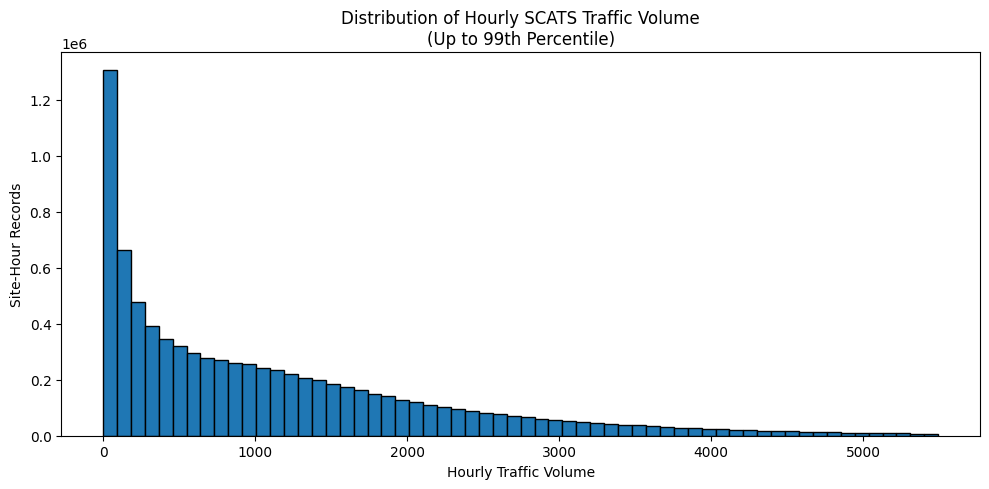


TRAFFIC PROFILE BY HOUR OF DAY
 Hour  Average_Traffic_Volume  Median_Traffic_Volume  Maximum_Traffic_Volume  Site_Hour_Records
    0                  327.08                  183.0                 19779.0             356322
    1                  240.66                  111.0                 24500.0             356322
    2                  176.86                   81.0                 25610.0             356322
    3                  161.79                   81.0                 23411.0             356322
    4                  217.44                  127.0                 21582.0             356322
    5                  508.16                  305.0                 20192.0             356322
    6                 1015.90                  659.0                 17790.0             356322
    7                 1348.19                  966.0                 22472.0             356322
    8                 1656.98                 1306.0                 27088.0             356322
    9   

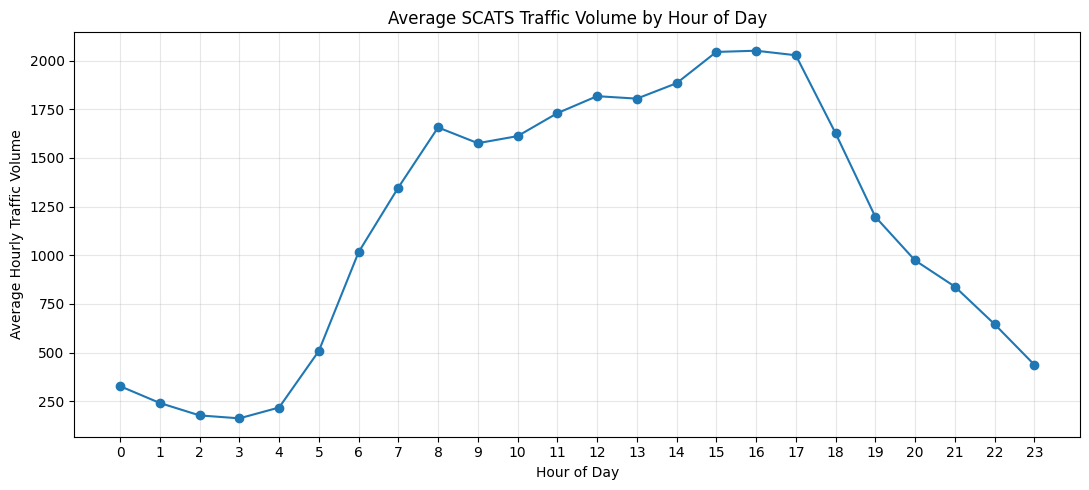


TOP 10 PEAK TRAFFIC HOURS
 Hour  Average_Traffic_Volume  Median_Traffic_Volume  Site_Hour_Records
   16                 2051.31                 1756.0             356322
   15                 2045.04                 1765.0             356322
   17                 2027.99                 1728.0             356322
   14                 1884.21                 1614.0             356322
   12                 1817.71                 1569.0             356322
   13                 1805.01                 1551.0             356322
   11                 1730.36                 1488.0             356322
    8                 1656.98                 1306.0             356322
   18                 1627.32                 1357.0             356322
   10                 1612.33                 1377.0             356322

YEAR-LEVEL TRAFFIC SUMMARY
 SOURCE_YEAR  Site_Hour_Records  Unique_Sites  Average_Hourly_Volume  Median_Hourly_Volume  Maximum_Hourly_Volume  Average_Active_Detectors
        2018 

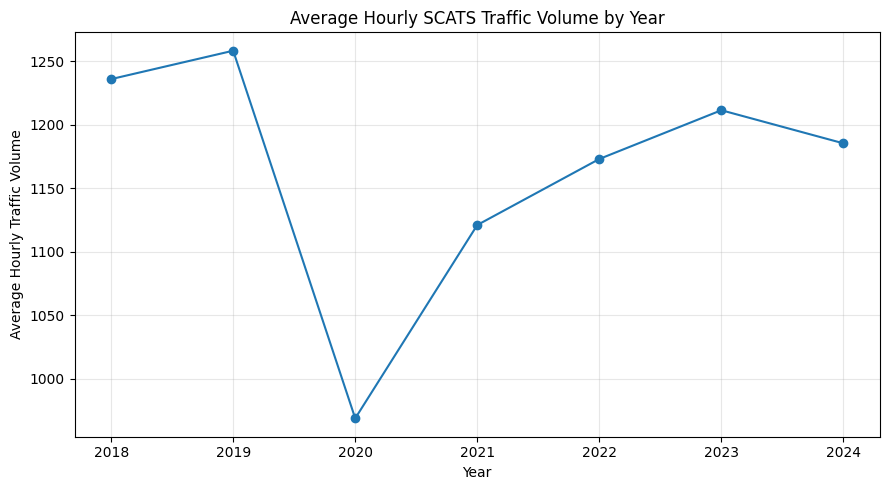


WEEKDAY VS WEEKEND TRAFFIC
Day_Type  Mean_Hourly_Volume  Median_Hourly_Volume  Site_Hour_Records
 Weekday         1210.637766                 851.0            6281976
 Weekend         1033.055538                 677.0            2269752


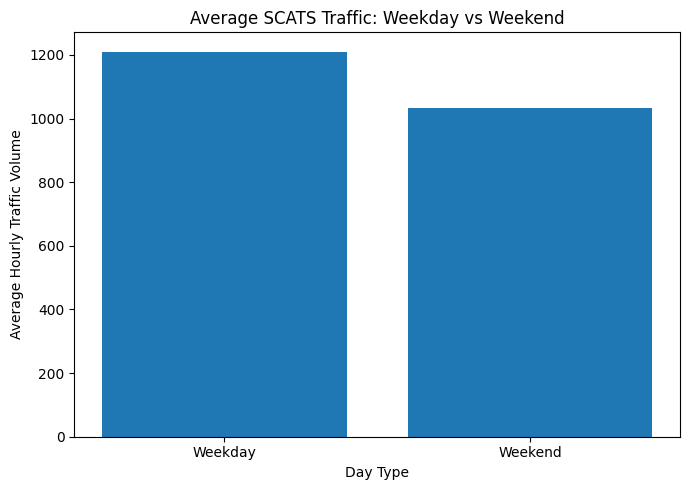


HOURLY PROFILE BY DAY TYPE
Day_Type  Hour  Average_Traffic_Volume
 Weekday     0              267.847037
 Weekday     1              199.554260
 Weekday     2              152.202748
 Weekday     3              146.267229
 Weekday     4              228.332574
 Weekday     5              600.828886
 Weekday     6             1226.458374
 Weekday     7             1619.118255
 Weekday     8             1925.163645
 Weekday     9             1659.570321
 Weekday    10             1598.616151
 Weekday    11             1682.923625
 Weekday    12             1765.457259
 Weekday    13             1777.359390
 Weekday    14             1905.799338
 Weekday    15             2139.777657
 Weekday    16             2170.426397
 Weekday    17             2154.878544
 Weekday    18             1708.483081
 Weekday    19             1231.737871
 Weekday    20              991.480418
 Weekday    21              847.646008
 Weekday    22              636.703254
 Weekday    23              418.6740

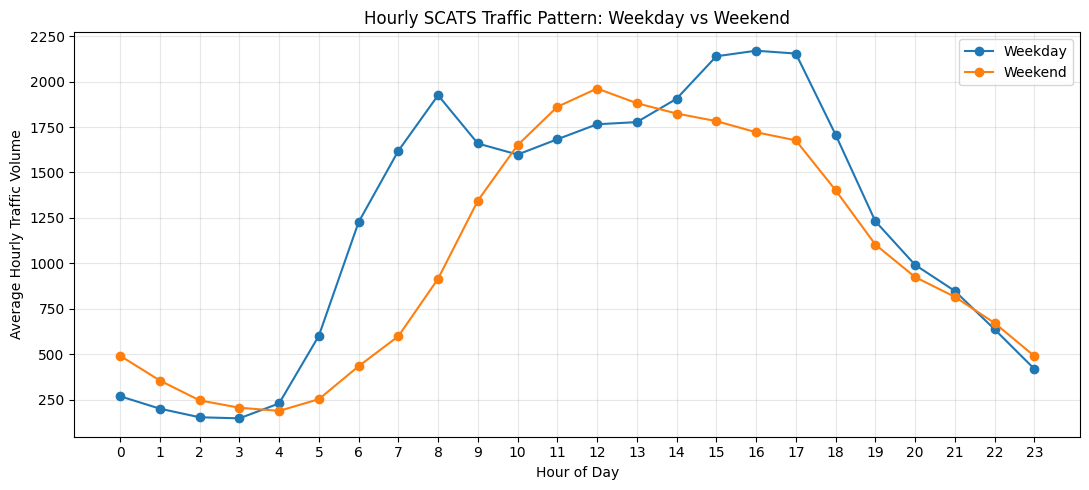


TOP 20 SCATS SITES BY AVERAGE HOURLY TRAFFIC
 NB_SCATS_SITE  Average_Hourly_Volume  Median_Hourly_Volume  Maximum_Hourly_Volume  Site_Hour_Records  Average_Active_Detectors
          4415            6265.714357                7013.0                10437.0               1992                 24.000000
          3380            6072.836847                6689.5                15751.0               1992                 30.626506
           849            5322.493474                5421.0                11670.0               1992                 24.000000
          3376            5205.893574                6029.0                 9366.0               1992                 24.000000
          2404            5062.609940                5420.5                 8918.0               1992                 23.566265
          2487            4999.208333                5494.5                 9037.0               1992                 24.000000
          3386            4930.378514                5564.

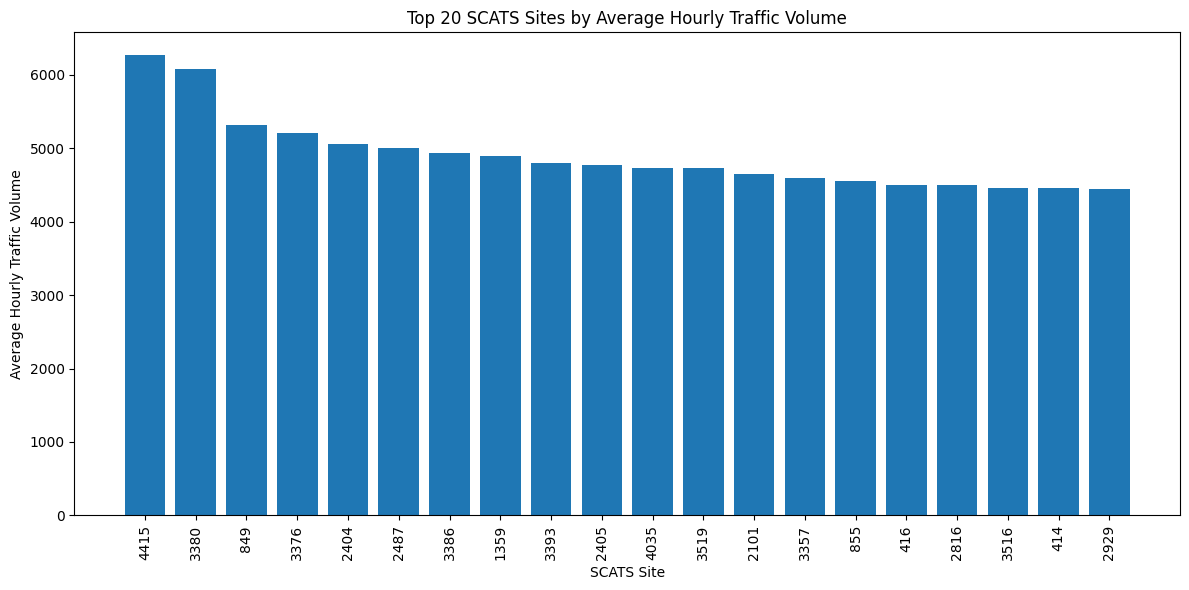


REGION-LEVEL TRAFFIC SUMMARY
                      NM_REGION  Average_Hourly_Volume  Median_Hourly_Volume  Maximum_Hourly_Volume  Site_Hour_Records  Unique_Sites
GLI                                        1964.344028                1384.0                 9588.0               7200            94
WV2                                        1894.993924                1559.0                 8412.0               9216           104
ES2                                        1836.441512                1537.0                 7978.0               6480            70
MC2                                        1793.000809                1241.5                13329.0               7416            95
                            GLI            1722.272521                1118.0                13637.0             198840           108
BBN                                        1699.317016                1316.0                11082.0              10296           123
GRE                                    

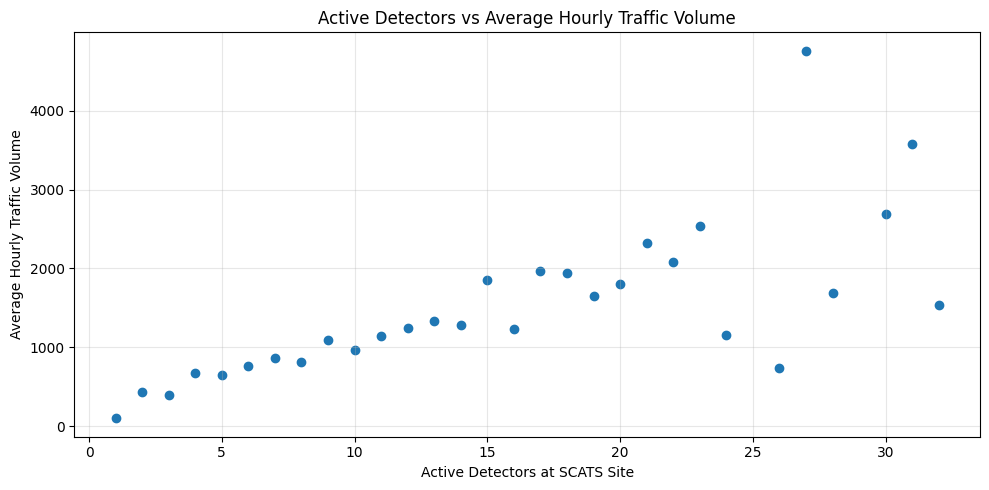


KEY EDA FINDINGS
Peak average traffic hour: 16:00
Peak-hour average volume: 2,051.31
Highest average traffic year: 2019
Lowest average traffic year: 2020
SCATS sites analysed: 4,704
Regions analysed: 74

CELL 8 OUTPUT OBJECTS
scats_eda_traffic_summary
scats_eda_hourly_profile
scats_eda_peak_hours
scats_eda_year_summary
scats_eda_day_type_summary
scats_eda_day_hour_profile
scats_eda_site_summary
scats_eda_site_ranking
scats_eda_region_summary
scats_eda_detector_relationship

CELL 8 SUMMARY
Hourly SCATS traffic EDA has been completed using the cleaned and aggregated dataset produced in Cell 6.
The analysis covers traffic distribution, hourly patterns, peak periods, yearly variation, weekday/weekend behaviour, site variation, regional variation and detector activity.
The resulting summary objects are retained for final pipeline validation in Cell 9.

Cell 8 completed successfully.


In [55]:
# ============================================================================
# CELL 8 - SCATS HOURLY TRAFFIC EXPLORATORY DATA ANALYSIS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 78)
print("SCATS DATASET - HOURLY TRAFFIC EXPLORATORY DATA ANALYSIS")
print("=" * 78)

# ============================================================================
# 1. USE THE HOURLY DATASET CREATED IN CELL 6
# ============================================================================

if "scats_hourly_sample" not in globals():
    raise NameError(
        "scats_hourly_sample is not available. "
        "Please run Cell 6 before Cell 8."
    )

hourly_df = scats_hourly_sample

print("\nINPUT DATASET")
print("-" * 78)
print("Object used: scats_hourly_sample")
print(f"Rows: {len(hourly_df):,}")
print(f"Columns: {len(hourly_df.columns)}")

print("\nDate range:")
print("Earliest:", hourly_df["Hourly_Timestamp"].min())
print("Latest  :", hourly_df["Hourly_Timestamp"].max())

print("\nYears represented:")
print(sorted(hourly_df["SOURCE_YEAR"].dropna().unique().tolist()))

print("\nUnique SCATS sites:")
print(f"{hourly_df['NB_SCATS_SITE'].nunique():,}")

print("\nRegions represented:")
print(f"{hourly_df['NM_REGION'].nunique():,}")


# ============================================================================
# 2. HOURLY TRAFFIC VOLUME DISTRIBUTION
# ============================================================================

print("\n" + "=" * 78)
print("HOURLY TRAFFIC VOLUME DISTRIBUTION")
print("=" * 78)

traffic_summary = (
    hourly_df["Hourly_Traffic_Volume"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

print(traffic_summary)

zero_hours = (
    hourly_df["Hourly_Traffic_Volume"] == 0
).sum()

negative_hours = (
    hourly_df["Hourly_Traffic_Volume"] < 0
).sum()

missing_hours = (
    hourly_df["Hourly_Traffic_Volume"]
    .isna()
    .sum()
)

print("\nQuality checks:")
print(f"Zero-volume site-hours     : {zero_hours:,}")
print(f"Negative-volume site-hours : {negative_hours:,}")
print(f"Missing-volume site-hours  : {missing_hours:,}")

print(
    "Zero-volume percentage    : "
    f"{zero_hours / len(hourly_df) * 100:.2f}%"
)


# ============================================================================
# 3. DISTRIBUTION PLOT
# ============================================================================

# Use the 99th percentile only for visualisation so extreme values
# do not compress the main traffic distribution.

upper_limit = (
    hourly_df["Hourly_Traffic_Volume"]
    .quantile(0.99)
)

plot_values = hourly_df.loc[
    hourly_df["Hourly_Traffic_Volume"] <= upper_limit,
    "Hourly_Traffic_Volume"
]

plt.figure(figsize=(10, 5))

plt.hist(
    plot_values,
    bins=60,
    edgecolor="black"
)

plt.title(
    "Distribution of Hourly SCATS Traffic Volume\n"
    "(Up to 99th Percentile)"
)

plt.xlabel("Hourly Traffic Volume")
plt.ylabel("Site-Hour Records")

plt.tight_layout()
plt.show()


# ============================================================================
# 4. TRAFFIC PATTERN BY HOUR OF DAY
# ============================================================================

if "scats_hourly_profile" in globals():
    hourly_pattern = scats_hourly_profile.copy()

else:
    hourly_pattern = (
        hourly_df
        .groupby("Hour")
        .agg(
            Average_Traffic_Volume=(
                "Hourly_Traffic_Volume",
                "mean"
            ),
            Median_Traffic_Volume=(
                "Hourly_Traffic_Volume",
                "median"
            ),
            Maximum_Traffic_Volume=(
                "Hourly_Traffic_Volume",
                "max"
            ),
            Site_Hour_Records=(
                "Hourly_Traffic_Volume",
                "size"
            )
        )
        .reset_index()
    )

hourly_pattern = hourly_pattern.sort_values("Hour")

print("\n" + "=" * 78)
print("TRAFFIC PROFILE BY HOUR OF DAY")
print("=" * 78)

print(hourly_pattern.to_string(index=False))

plt.figure(figsize=(11, 5))

plt.plot(
    hourly_pattern["Hour"],
    hourly_pattern["Average_Traffic_Volume"],
    marker="o"
)

plt.title("Average SCATS Traffic Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Traffic Volume")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 5. IDENTIFY PEAK TRAFFIC HOURS
# ============================================================================

peak_hours = (
    hourly_pattern
    .sort_values(
        "Average_Traffic_Volume",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 78)
print("TOP 10 PEAK TRAFFIC HOURS")
print("=" * 78)

print(
    peak_hours[
        [
            "Hour",
            "Average_Traffic_Volume",
            "Median_Traffic_Volume",
            "Site_Hour_Records"
        ]
    ]
    .head(10)
    .to_string(index=False)
)


# ============================================================================
# 6. YEAR-LEVEL TRAFFIC ANALYSIS
# ============================================================================

if "scats_hourly_year_summary" in globals():
    yearly_pattern = scats_hourly_year_summary.copy()

else:
    yearly_pattern = (
        hourly_df
        .groupby("SOURCE_YEAR")
        .agg(
            Site_Hour_Records=(
                "Hourly_Traffic_Volume",
                "size"
            ),
            Unique_Sites=(
                "NB_SCATS_SITE",
                "nunique"
            ),
            Average_Hourly_Volume=(
                "Hourly_Traffic_Volume",
                "mean"
            ),
            Median_Hourly_Volume=(
                "Hourly_Traffic_Volume",
                "median"
            ),
            Maximum_Hourly_Volume=(
                "Hourly_Traffic_Volume",
                "max"
            ),
            Average_Active_Detectors=(
                "Active_Detectors",
                "mean"
            )
        )
        .reset_index()
    )

yearly_pattern = yearly_pattern.sort_values("SOURCE_YEAR")

print("\n" + "=" * 78)
print("YEAR-LEVEL TRAFFIC SUMMARY")
print("=" * 78)

print(yearly_pattern.to_string(index=False))

plt.figure(figsize=(9, 5))

plt.plot(
    yearly_pattern["SOURCE_YEAR"],
    yearly_pattern["Average_Hourly_Volume"],
    marker="o"
)

plt.title("Average Hourly SCATS Traffic Volume by Year")
plt.xlabel("Year")
plt.ylabel("Average Hourly Traffic Volume")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 7. WEEKDAY VS WEEKEND
# ============================================================================

# Work only with the columns needed for this analysis.
# This avoids creating an unnecessary full copy of the 8.5M-row dataset.

day_analysis = hourly_df[
    [
        "Date",
        "Hour",
        "Hourly_Traffic_Volume"
    ]
].copy()

day_analysis["Date"] = pd.to_datetime(
    day_analysis["Date"],
    errors="coerce"
)

day_analysis["Day_Type"] = np.where(
    day_analysis["Date"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

day_type_summary = (
    day_analysis
    .groupby("Day_Type")
    .agg(
        Mean_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),
        Median_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),
        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        )
    )
    .reset_index()
)

print("\n" + "=" * 78)
print("WEEKDAY VS WEEKEND TRAFFIC")
print("=" * 78)

print(day_type_summary.to_string(index=False))

plt.figure(figsize=(7, 5))

plt.bar(
    day_type_summary["Day_Type"],
    day_type_summary["Mean_Hourly_Volume"]
)

plt.title("Average SCATS Traffic: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Hourly Traffic Volume")

plt.tight_layout()
plt.show()


# ============================================================================
# 8. WEEKDAY/WEEKEND HOURLY PROFILE
# ============================================================================

day_hour_profile = (
    day_analysis
    .groupby(
        [
            "Day_Type",
            "Hour"
        ]
    )["Hourly_Traffic_Volume"]
    .mean()
    .reset_index(
        name="Average_Traffic_Volume"
    )
)

print("\n" + "=" * 78)
print("HOURLY PROFILE BY DAY TYPE")
print("=" * 78)

print(day_hour_profile.to_string(index=False))

plt.figure(figsize=(11, 5))

for day_type in ["Weekday", "Weekend"]:

    temp = (
        day_hour_profile[
            day_hour_profile["Day_Type"] == day_type
        ]
        .sort_values("Hour")
    )

    if not temp.empty:

        plt.plot(
            temp["Hour"],
            temp["Average_Traffic_Volume"],
            marker="o",
            label=day_type
        )

plt.title(
    "Hourly SCATS Traffic Pattern: Weekday vs Weekend"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Traffic Volume")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 9. SCATS SITE-LEVEL ANALYSIS
# ============================================================================

site_summary = (
    hourly_df
    .groupby("NB_SCATS_SITE")
    .agg(
        Average_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),
        Median_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),
        Maximum_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "max"
        ),
        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        ),
        Average_Active_Detectors=(
            "Active_Detectors",
            "mean"
        )
    )
    .reset_index()
)

# Require a reasonable number of observations before ranking a site.
minimum_site_records = 100

site_ranking = (
    site_summary[
        site_summary["Site_Hour_Records"]
        >= minimum_site_records
    ]
    .sort_values(
        "Average_Hourly_Volume",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 78)
print("TOP 20 SCATS SITES BY AVERAGE HOURLY TRAFFIC")
print("=" * 78)

print(
    site_ranking
    .head(20)
    .to_string(index=False)
)

top20_sites = site_ranking.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top20_sites[
        "NB_SCATS_SITE"
    ].astype(str),
    top20_sites[
        "Average_Hourly_Volume"
    ]
)

plt.title(
    "Top 20 SCATS Sites by Average Hourly Traffic Volume"
)

plt.xlabel("SCATS Site")
plt.ylabel("Average Hourly Traffic Volume")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


# ============================================================================
# 10. REGION-LEVEL ANALYSIS
# ============================================================================

region_summary = (
    hourly_df
    .groupby("NM_REGION")
    .agg(
        Average_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),
        Median_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),
        Maximum_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "max"
        ),
        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        ),
        Unique_Sites=(
            "NB_SCATS_SITE",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Hourly_Volume",
        ascending=False
    )
)

print("\n" + "=" * 78)
print("REGION-LEVEL TRAFFIC SUMMARY")
print("=" * 78)

print(
    region_summary
    .head(20)
    .to_string(index=False)
)


# ============================================================================
# 11. ACTIVE DETECTORS VS TRAFFIC VOLUME
# ============================================================================

detector_relationship = (
    hourly_df
    .groupby("Active_Detectors")
    .agg(
        Average_Traffic_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),
        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        )
    )
    .reset_index()
)

# Only show detector counts with enough observations.
detector_plot = detector_relationship[
    detector_relationship["Site_Hour_Records"] >= 100
].copy()

print("\n" + "=" * 78)
print("ACTIVE DETECTOR SUMMARY")
print("=" * 78)

print(
    detector_plot
    .head(30)
    .to_string(index=False)
)

plt.figure(figsize=(10, 5))

plt.scatter(
    detector_plot["Active_Detectors"],
    detector_plot["Average_Traffic_Volume"]
)

plt.title(
    "Active Detectors vs Average Hourly Traffic Volume"
)

plt.xlabel("Active Detectors at SCATS Site")
plt.ylabel("Average Hourly Traffic Volume")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 12. EDA FINDINGS
# ============================================================================

highest_hour = peak_hours.iloc[0]

highest_year = yearly_pattern.loc[
    yearly_pattern[
        "Average_Hourly_Volume"
    ].idxmax()
]

lowest_year = yearly_pattern.loc[
    yearly_pattern[
        "Average_Hourly_Volume"
    ].idxmin()
]

print("\n" + "=" * 78)
print("KEY EDA FINDINGS")
print("=" * 78)

print(
    f"Peak average traffic hour: "
    f"{int(highest_hour['Hour']):02d}:00"
)

print(
    "Peak-hour average volume:",
    f"{highest_hour['Average_Traffic_Volume']:,.2f}"
)

print(
    "Highest average traffic year:",
    int(highest_year["SOURCE_YEAR"])
)

print(
    "Lowest average traffic year:",
    int(lowest_year["SOURCE_YEAR"])
)

print(
    "SCATS sites analysed:",
    f"{hourly_df['NB_SCATS_SITE'].nunique():,}"
)

print(
    "Regions analysed:",
    f"{hourly_df['NM_REGION'].nunique():,}"
)


# ============================================================================
# 13. OUTPUT OBJECTS FOR CELL 9
# ============================================================================

scats_eda_traffic_summary = traffic_summary
scats_eda_hourly_profile = hourly_pattern
scats_eda_peak_hours = peak_hours
scats_eda_year_summary = yearly_pattern
scats_eda_day_type_summary = day_type_summary
scats_eda_day_hour_profile = day_hour_profile
scats_eda_site_summary = site_summary
scats_eda_site_ranking = site_ranking
scats_eda_region_summary = region_summary
scats_eda_detector_relationship = detector_relationship


# Release the large temporary copy.
del day_analysis


print("\n" + "=" * 78)
print("CELL 8 OUTPUT OBJECTS")
print("=" * 78)

print("scats_eda_traffic_summary")
print("scats_eda_hourly_profile")
print("scats_eda_peak_hours")
print("scats_eda_year_summary")
print("scats_eda_day_type_summary")
print("scats_eda_day_hour_profile")
print("scats_eda_site_summary")
print("scats_eda_site_ranking")
print("scats_eda_region_summary")
print("scats_eda_detector_relationship")


print("\n" + "=" * 78)
print("CELL 8 SUMMARY")
print("=" * 78)

print(
    "Hourly SCATS traffic EDA has been completed using "
    "the cleaned and aggregated dataset produced in Cell 6."
)

print(
    "The analysis covers traffic distribution, hourly patterns, "
    "peak periods, yearly variation, weekday/weekend behaviour, "
    "site variation, regional variation and detector activity."
)

print(
    "The resulting summary objects are retained for final "
    "pipeline validation in Cell 9."
)

print("\nCell 8 completed successfully.")

In [57]:
# ============================================================================
# CELL 9 - FINAL SCATS PIPELINE VALIDATION AND SERVING DATASET PREPARATION
# ============================================================================
#
# Purpose:
#   Finalise the hourly SCATS traffic dataset after preprocessing and EDA.
#
# User story:
#   "As a Data Engineer, I want to build a pipeline that aggregates event
#   streams into hourly average occupancy rates and traffic volumes so that
#   data is summarized for performant serving."
#
# This cell:
#   1. Validates the hourly dataset created in Cell 6
#   2. Cleans region labels
#   3. Removes invalid / unusable records
#   4. Checks duplicate site-hour observations
#   5. Creates a compact serving-ready hourly traffic table
#   6. Creates daily and yearly validation summaries
#   7. Exports final processed datasets
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
import gc


print("=" * 80)
print("SCATS DATASET - FINAL PIPELINE PREPARATION")
print("=" * 80)


# ============================================================================
# 1. INPUT VALIDATION
# ============================================================================

print("\nINPUT DATA CHECK")
print("-" * 80)

if "scats_hourly_sample" not in globals():
    raise NameError(
        "scats_hourly_sample was not found.\n"
        "Please run Cell 6 before running Cell 9."
    )

required_columns = [
    "SOURCE_YEAR",
    "SOURCE_MONTH",
    "Date",
    "Hourly_Timestamp",
    "Hour",
    "NB_SCATS_SITE",
    "NM_REGION",
    "Hourly_Traffic_Volume",
    "Active_Detectors"
]

missing_columns = [
    col for col in required_columns
    if col not in scats_hourly_sample.columns
]

if missing_columns:
    raise KeyError(
        "Required columns are missing: "
        + ", ".join(missing_columns)
    )

print(
    "Input site-hour records:",
    f"{len(scats_hourly_sample):,}"
)

print(
    "Input columns:",
    len(scats_hourly_sample.columns)
)

print(
    "Years:",
    sorted(
        scats_hourly_sample[
            "SOURCE_YEAR"
        ].dropna().unique()
    )
)

print(
    "Unique SCATS sites:",
    f"{scats_hourly_sample['NB_SCATS_SITE'].nunique():,}"
)

print(
    "Raw region labels:",
    scats_hourly_sample["NM_REGION"].nunique(
        dropna=True
    )
)


# ============================================================================
# 2. CREATE WORKING DATASET
# ============================================================================

# Keep only fields needed for the serving layer.
# This reduces memory usage compared with copying all Cell 6 diagnostic fields.

serving_columns = [
    "SOURCE_YEAR",
    "SOURCE_MONTH",
    "Date",
    "Hourly_Timestamp",
    "Hour",
    "NB_SCATS_SITE",
    "NM_REGION",
    "Hourly_Traffic_Volume",
    "Active_Detectors"
]

scats_hourly_serving = (
    scats_hourly_sample[
        serving_columns
    ]
    .copy()
)


# ============================================================================
# 3. CLEAN DATA TYPES
# ============================================================================

print("\n" + "=" * 80)
print("DATA TYPE STANDARDISATION")
print("=" * 80)

scats_hourly_serving["Date"] = pd.to_datetime(
    scats_hourly_serving["Date"],
    errors="coerce"
)

scats_hourly_serving[
    "Hourly_Timestamp"
] = pd.to_datetime(
    scats_hourly_serving[
        "Hourly_Timestamp"
    ],
    errors="coerce"
)

for col in [
    "SOURCE_YEAR",
    "SOURCE_MONTH",
    "Hour",
    "NB_SCATS_SITE",
    "Active_Detectors"
]:

    scats_hourly_serving[col] = pd.to_numeric(
        scats_hourly_serving[col],
        errors="coerce"
    )

scats_hourly_serving[
    "Hourly_Traffic_Volume"
] = pd.to_numeric(
    scats_hourly_serving[
        "Hourly_Traffic_Volume"
    ],
    errors="coerce"
)


# ============================================================================
# 4. CLEAN REGION LABELS
# ============================================================================

print("\n" + "=" * 80)
print("REGION LABEL CLEANING")
print("=" * 80)

regions_before = (
    scats_hourly_serving[
        "NM_REGION"
    ]
    .nunique(dropna=True)
)

# Convert to pandas string type.
scats_hourly_serving[
    "NM_REGION"
] = (
    scats_hourly_serving[
        "NM_REGION"
    ]
    .astype("string")
)

# Remove leading/trailing spaces and repeated internal whitespace.
scats_hourly_serving[
    "NM_REGION"
] = (
    scats_hourly_serving[
        "NM_REGION"
    ]
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.upper()
)

# Convert blank strings to missing.
scats_hourly_serving.loc[
    scats_hourly_serving[
        "NM_REGION"
    ].isin(
        [
            "",
            "NAN",
            "NONE",
            "<NA>"
        ]
    ),
    "NM_REGION"
] = pd.NA


regions_after = (
    scats_hourly_serving[
        "NM_REGION"
    ]
    .nunique(dropna=True)
)

print(
    "Region labels before cleaning:",
    regions_before
)

print(
    "Region labels after cleaning:",
    regions_after
)

print(
    "Region labels consolidated:",
    regions_before - regions_after
)

print(
    "Missing region records:",
    f"{scats_hourly_serving['NM_REGION'].isna().sum():,}"
)


# ============================================================================
# 5. INVALID RECORD CHECK
# ============================================================================

print("\n" + "=" * 80)
print("FINAL RECORD QUALITY CHECK")
print("=" * 80)

quality_before = len(
    scats_hourly_serving
)

invalid_timestamp = (
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].isna()
).sum()

invalid_site = (
    scats_hourly_serving[
        "NB_SCATS_SITE"
    ].isna()
).sum()

invalid_volume = (
    scats_hourly_serving[
        "Hourly_Traffic_Volume"
    ].isna()
).sum()

negative_volume = (
    scats_hourly_serving[
        "Hourly_Traffic_Volume"
    ] < 0
).sum()

invalid_hour = (
    ~scats_hourly_serving[
        "Hour"
    ].between(
        0,
        23,
        inclusive="both"
    )
).sum()


print(
    "Missing hourly timestamps:",
    f"{invalid_timestamp:,}"
)

print(
    "Missing SCATS site IDs:",
    f"{invalid_site:,}"
)

print(
    "Missing hourly traffic volumes:",
    f"{invalid_volume:,}"
)

print(
    "Negative hourly traffic volumes:",
    f"{negative_volume:,}"
)

print(
    "Invalid hour values:",
    f"{invalid_hour:,}"
)


# Remove records that cannot be served reliably.
scats_hourly_serving = (
    scats_hourly_serving[
        scats_hourly_serving[
            "Hourly_Timestamp"
        ].notna()
        &
        scats_hourly_serving[
            "NB_SCATS_SITE"
        ].notna()
        &
        scats_hourly_serving[
            "Hourly_Traffic_Volume"
        ].notna()
        &
        (
            scats_hourly_serving[
                "Hourly_Traffic_Volume"
            ] >= 0
        )
        &
        scats_hourly_serving[
            "Hour"
        ].between(
            0,
            23,
            inclusive="both"
        )
    ]
    .copy()
)


quality_after = len(
    scats_hourly_serving
)

print(
    "\nRecords before final validation:",
    f"{quality_before:,}"
)

print(
    "Records after final validation:",
    f"{quality_after:,}"
)

print(
    "Records removed:",
    f"{quality_before - quality_after:,}"
)


# ============================================================================
# 6. DUPLICATE SITE-HOUR CHECK
# ============================================================================

print("\n" + "=" * 80)
print("SITE-HOUR UNIQUENESS CHECK")
print("=" * 80)

duplicate_key = [
    "Hourly_Timestamp",
    "NB_SCATS_SITE"
]

duplicate_site_hours = (
    scats_hourly_serving
    .duplicated(
        subset=duplicate_key,
        keep=False
    )
)

duplicate_count = (
    duplicate_site_hours.sum()
)

print(
    "Records participating in duplicate site-hours:",
    f"{duplicate_count:,}"
)

if duplicate_count == 0:

    print(
        "PASS: Each SCATS site has one record per hourly timestamp."
    )

else:

    print(
        "Duplicate site-hour records detected."
    )

    print(
        "They will be consolidated before serving."
    )

    # Defensive aggregation:
    # protects the final serving table if the same site-hour
    # appears more than once because of source/schema differences.

    scats_hourly_serving = (
        scats_hourly_serving
        .groupby(
            [
                "SOURCE_YEAR",
                "SOURCE_MONTH",
                "Date",
                "Hourly_Timestamp",
                "Hour",
                "NB_SCATS_SITE"
            ],
            dropna=False,
            as_index=False
        )
        .agg(
            NM_REGION=(
                "NM_REGION",
                "first"
            ),

            Hourly_Traffic_Volume=(
                "Hourly_Traffic_Volume",
                "sum"
            ),

            Active_Detectors=(
                "Active_Detectors",
                "max"
            )
        )
    )


print(
    "Final site-hour records:",
    f"{len(scats_hourly_serving):,}"
)


# ============================================================================
# 7. CREATE SERVING FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("SERVING FEATURES")
print("=" * 80)

scats_hourly_serving[
    "Day_of_Week"
] = (
    scats_hourly_serving[
        "Hourly_Timestamp"
    ]
    .dt.day_name()
)

scats_hourly_serving[
    "Day_Type"
] = np.where(
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

scats_hourly_serving[
    "Year"
] = (
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].dt.year
)

scats_hourly_serving[
    "Month"
] = (
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].dt.month
)

scats_hourly_serving[
    "Day"
] = (
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].dt.day
)


# More compact integer types where safe.
for col in [
    "SOURCE_YEAR",
    "SOURCE_MONTH",
    "Year",
    "Month",
    "Day",
    "Hour"
]:

    scats_hourly_serving[col] = (
        scats_hourly_serving[col]
        .astype("Int16")
    )

scats_hourly_serving[
    "NB_SCATS_SITE"
] = (
    scats_hourly_serving[
        "NB_SCATS_SITE"
    ]
    .astype("Int32")
)

scats_hourly_serving[
    "Active_Detectors"
] = (
    scats_hourly_serving[
        "Active_Detectors"
    ]
    .astype("Int16")
)

scats_hourly_serving[
    "Hourly_Traffic_Volume"
] = (
    scats_hourly_serving[
        "Hourly_Traffic_Volume"
    ]
    .astype("float32")
)


# Sort for efficient time/site access.
scats_hourly_serving = (
    scats_hourly_serving
    .sort_values(
        [
            "Hourly_Timestamp",
            "NB_SCATS_SITE"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================================
# 8. FINAL REGION SUMMARY AFTER CLEANING
# ============================================================================

scats_final_region_summary = (
    scats_hourly_serving
    .groupby(
        "NM_REGION",
        dropna=False
    )
    .agg(
        Average_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),

        Median_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),

        Maximum_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "max"
        ),

        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        ),

        Unique_Sites=(
            "NB_SCATS_SITE",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "Average_Hourly_Volume",
        ascending=False
    )
)


print("\n" + "=" * 80)
print("TOP REGIONS AFTER LABEL CLEANING")
print("=" * 80)

print(
    scats_final_region_summary
    .head(20)
    .to_string(index=False)
)


# ============================================================================
# 9. YEAR-LEVEL SERVING VALIDATION
# ============================================================================

scats_final_year_summary = (
    scats_hourly_serving
    .groupby("SOURCE_YEAR")
    .agg(
        Site_Hour_Records=(
            "Hourly_Traffic_Volume",
            "size"
        ),

        Unique_Sites=(
            "NB_SCATS_SITE",
            "nunique"
        ),

        Average_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "mean"
        ),

        Median_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "median"
        ),

        Maximum_Hourly_Volume=(
            "Hourly_Traffic_Volume",
            "max"
        )
    )
    .reset_index()
)


print("\n" + "=" * 80)
print("FINAL YEAR-LEVEL VALIDATION")
print("=" * 80)

print(
    scats_final_year_summary
    .to_string(index=False)
)


# ============================================================================
# 10. PIPELINE SERVING SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("FINAL SERVING DATASET SUMMARY")
print("=" * 80)

print(
    "Serving records:",
    f"{len(scats_hourly_serving):,}"
)

print(
    "Columns:",
    len(scats_hourly_serving.columns)
)

print(
    "Unique SCATS sites:",
    f"{scats_hourly_serving['NB_SCATS_SITE'].nunique():,}"
)

print(
    "Clean unique regions:",
    scats_hourly_serving[
        "NM_REGION"
    ].nunique(dropna=True)
)

print(
    "Earliest timestamp:",
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].min()
)

print(
    "Latest timestamp:",
    scats_hourly_serving[
        "Hourly_Timestamp"
    ].max()
)

print(
    "Minimum hourly volume:",
    scats_hourly_serving[
        "Hourly_Traffic_Volume"
    ].min()
)

print(
    "Maximum hourly volume:",
    scats_hourly_serving[
        "Hourly_Traffic_Volume"
    ].max()
)

print(
    "Average hourly volume:",
    round(
        scats_hourly_serving[
            "Hourly_Traffic_Volume"
        ].mean(),
        2
    )
)

print(
    "Missing traffic volumes:",
    f"{scats_hourly_serving['Hourly_Traffic_Volume'].isna().sum():,}"
)

print(
    "Negative traffic volumes:",
    f"{(scats_hourly_serving['Hourly_Traffic_Volume'] < 0).sum():,}"
)


# ============================================================================
# 11. SAMPLE FINAL SERVING RECORDS
# ============================================================================

print("\n" + "=" * 80)
print("SAMPLE SERVING RECORDS")
print("=" * 80)

display(
    scats_hourly_serving.head(20)
)


# ============================================================================
# 12. EXPORT FINAL DATA
# ============================================================================

processed_folder = (
    SCATS_FOLDER.parent
    / "Processed"
    / "SCATS"
)

processed_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("\n" + "=" * 80)
print("EXPORTING FINAL SCATS OUTPUTS")
print("=" * 80)

print(
    "Output folder:",
    processed_folder
)


# Parquet is preferred for the large hourly dataset because it is
# considerably smaller and faster to query than CSV.

hourly_output_path = (
    processed_folder
    / "scats_hourly_traffic_sample_2018_2024.parquet"
)

region_output_path = (
    processed_folder
    / "scats_region_summary_2018_2024.csv"
)

year_output_path = (
    processed_folder
    / "scats_year_summary_2018_2024.csv"
)


try:

    scats_hourly_serving.to_parquet(
        hourly_output_path,
        index=False
    )

    print(
        "\nHourly serving dataset saved:"
    )

    print(
        hourly_output_path
    )

except Exception as error:

    print(
        "\nParquet export could not be completed:"
    )

    print(error)

    print(
        "\nInstall pyarrow if required using:"
    )

    print(
        "pip install pyarrow"
    )


scats_final_region_summary.to_csv(
    region_output_path,
    index=False
)

scats_final_year_summary.to_csv(
    year_output_path,
    index=False
)

print(
    "\nRegion summary saved:"
)

print(
    region_output_path
)

print(
    "\nYear summary saved:"
)

print(
    year_output_path
)


# ============================================================================
# 13. FINAL OUTPUT OBJECTS
# ============================================================================

scats_pipeline_serving = (
    scats_hourly_serving
)

scats_pipeline_region_summary = (
    scats_final_region_summary
)

scats_pipeline_year_summary = (
    scats_final_year_summary
)


gc.collect()


print("\n" + "=" * 80)
print("CELL 9 OUTPUT OBJECTS")
print("=" * 80)

print(
    "scats_pipeline_serving:",
    f"{len(scats_pipeline_serving):,}",
    "site-hour records"
)

print(
    "scats_pipeline_region_summary:",
    len(scats_pipeline_region_summary),
    "region records"
)

print(
    "scats_pipeline_year_summary:",
    len(scats_pipeline_year_summary),
    "year records"
)


# ============================================================================
# 14. FINAL PIPELINE STATUS
# ============================================================================

print("\n" + "=" * 80)
print("SCATS PIPELINE STATUS")
print("=" * 80)

validation_passed = (
    scats_pipeline_serving[
        "Hourly_Traffic_Volume"
    ].isna().sum() == 0
    and
    (
        scats_pipeline_serving[
            "Hourly_Traffic_Volume"
        ] < 0
    ).sum() == 0
    and
    scats_pipeline_serving[
        "Hour"
    ].between(
        0,
        23,
        inclusive="both"
    ).all()
)


if validation_passed:

    print(
        "PASS: Final hourly SCATS traffic dataset "
        "is clean and serving-ready."
    )

else:

    print(
        "WARNING: One or more final validation "
        "conditions failed."
    )


print("\nSCATS DATASET WORK COMPLETED")

print(
    "\nThe SCATS traffic-volume data has now passed through:"
)

print(
    "1. File discovery and structure inspection"
)

print(
    "2. Schema inspection"
)

print(
    "3. Representative multi-year sampling"
)

print(
    "4. Data-quality profiling"
)

print(
    "5. 15-minute to hourly traffic aggregation"
)

print(
    "6. Negative-value investigation"
)

print(
    "7. Hourly exploratory data analysis"
)

print(
    "8. Region normalisation and final pipeline validation"
)

print(
    "9. Serving-ready dataset preparation and export"
)

print(
    "\nCell 9 completed."
)

SCATS DATASET - FINAL PIPELINE PREPARATION

INPUT DATA CHECK
--------------------------------------------------------------------------------
Input site-hour records: 8,551,728
Input columns: 13
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Unique SCATS sites: 4,704
Raw region labels: 74

DATA TYPE STANDARDISATION

REGION LABEL CLEANING
Region labels before cleaning: 74
Region labels after cleaning: 40
Region labels consolidated: 34
Missing region records: 0

FINAL RECORD QUALITY CHECK
Missing hourly timestamps: 0
Missing SCATS site IDs: 0
Missing hourly traffic volumes: 0
Negative hourly traffic volumes: 0
Invalid hour values: 0

Records before final validation: 8,551,728
Records after final validation: 8,551,728
Records removed: 0

SITE-HOUR UNIQUENESS CHECK
Records participating in duplicate site-hours: 240
Duplicate site-hour records detected.
They will be consolidated before serving.
Final site-hour records: 8,551,608

SERVING FEATURES

TOP REGIONS AFTER LABEL CLEANING
NM_REGI

,SOURCE_YEAR,SOURCE_MONTH,Date,Hourly_Timestamp,Hour,NB_SCATS_SITE,NM_REGION,Hourly_Traffic_Volume,Active_Detectors,Day_of_Week,Day_Type,Year,Month,Day
0,2018,1,2018-01-01,2018-01-01,0,100,WV1,580.0,24,Monday,Weekday,2018,1,1
1,2018,1,2018-01-01,2018-01-01,0,101,MEN,373.0,24,Monday,Weekday,2018,1,1
2,2018,1,2018-01-01,2018-01-01,0,102,CRN,447.0,24,Monday,Weekday,2018,1,1
3,2018,1,2018-01-01,2018-01-01,0,103,CRN,267.0,24,Monday,Weekday,2018,1,1
4,2018,1,2018-01-01,2018-01-01,0,104,VIC,403.0,24,Monday,Weekday,2018,1,1
5,2018,1,2018-01-01,2018-01-01,0,105,BBN,915.0,24,Monday,Weekday,2018,1,1
6,2018,1,2018-01-01,2018-01-01,0,106,CRN,356.0,24,Monday,Weekday,2018,1,1
7,2018,1,2018-01-01,2018-01-01,0,107,CRN,837.0,24,Monday,Weekday,2018,1,1
8,2018,1,2018-01-01,2018-01-01,0,108,BBN,353.0,24,Monday,Weekday,2018,1,1
9,2018,1,2018-01-01,2018-01-01,0,109,CRN,539.0,24,Monday,Weekday,2018,1,1



EXPORTING FINAL SCATS OUTPUTS
Output folder: C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\Processed\SCATS

Parquet export could not be completed:
Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

Install pyarrow if required using:
pip install pyarrow

Region summary saved:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\Processed\SCATS\scats_region_summary_2018_2024.csv

Year summary saved:
C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\Processed\SCATS\scats_year_summary_2018_2024.csv

CELL 9 OUTPUT OBJECTS
scats_pipeline_serving: 8,551,608 site-hour records
scats_pipeline_region_summar

In [59]:
!pip install pyarrow

   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   -- ------------------------------------- 1.6/28.0 MB 8.4 MB/s eta 0:00:04
   ---- ----------------------------------- 3.1/28.0 MB 8.8 MB/s eta 0:00:03
   ------ --------------------------------- 4.7/28.0 MB 7.7 MB/s eta 0:00:04
   --------- ------------------------------ 6.3/28.0 MB 8.2 MB/s eta 0:00:03
   ------------ --------------------------- 8.4/28.0 MB 8.4 MB/s eta 0:00:03
   --------------- ------------------------ 10.5/28.0 MB 8.6 MB/s eta 0:00:03
   ------------------ --------------------- 12.6/28.0 MB 8.9 MB/s eta 0:00:02
   -------------------- ------------------- 14.2/28.0 MB 8.6 MB/s eta 0:00:02
   ---------------------- ----------------- 15.7/28.0 MB 8.5 MB/s eta 0:00:02
   ------------------------- -------------- 18.1/28.0 MB 8.8 MB/s eta 0:00:02
   ---------------------------- ----------- 20.2/28.0 MB 9.0 MB/s eta 0:00:01
   -------------------------------- ------- 22.5/28.0 MB 9.2 MB/s eta 0:00:01

In [63]:
# ============================================================
# SCATS PARQUET EXPORT - FASTPARQUET FALLBACK
# ============================================================

import sys
import subprocess

print("=" * 80)
print("SCATS PARQUET EXPORT - FASTPARQUET")
print("=" * 80)

# ------------------------------------------------------------
# 1. INSTALL FASTPARQUET IF REQUIRED
# ------------------------------------------------------------

try:
    import fastparquet
    print("\nfastparquet already installed.")
    print("Version:", fastparquet.__version__)

except ImportError:

    print("\nfastparquet is not installed.")
    print("Installing fastparquet...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "fastparquet"
    ])

    import fastparquet

    print("fastparquet installed successfully.")
    print("Version:", fastparquet.__version__)


# ------------------------------------------------------------
# 2. CHECK SERVING DATASET
# ------------------------------------------------------------

if "scats_pipeline_serving" not in globals():

    raise NameError(
        "scats_pipeline_serving is not available in memory. "
        "Do not continue until the Cell 9 dataframe exists."
    )


print("\n" + "=" * 80)
print("INPUT DATASET")
print("=" * 80)

print(
    "Rows:",
    f"{len(scats_pipeline_serving):,}"
)

print(
    "Columns:",
    len(scats_pipeline_serving.columns)
)


# ------------------------------------------------------------
# 3. OUTPUT LOCATION
# ------------------------------------------------------------

from pathlib import Path

processed_folder = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\Processed\SCATS"
)

processed_folder.mkdir(
    parents=True,
    exist_ok=True
)

hourly_output_path = (
    processed_folder
    / "scats_hourly_traffic_sample_2018_2024.parquet"
)


# ------------------------------------------------------------
# 4. EXPORT USING FASTPARQUET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXPORTING PARQUET")
print("=" * 80)

print(
    "Output file:",
    hourly_output_path
)

scats_pipeline_serving.to_parquet(
    hourly_output_path,
    engine="fastparquet",
    index=False,
    compression="snappy"
)


# ------------------------------------------------------------
# 5. VERIFY OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXPORT VALIDATION")
print("=" * 80)

print(
    "File exists:",
    hourly_output_path.exists()
)

if hourly_output_path.exists():

    file_size_mb = (
        hourly_output_path.stat().st_size
        / (1024 ** 2)
    )

    file_size_gb = (
        hourly_output_path.stat().st_size
        / (1024 ** 3)
    )

    print(
        "File size:",
        f"{file_size_mb:,.2f} MB"
    )

    print(
        "File size:",
        f"{file_size_gb:.3f} GB"
    )


# ------------------------------------------------------------
# 6. READ-BACK TEST
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PARQUET READ-BACK TEST")
print("=" * 80)

test_df = (
    __import__("pandas")
    .read_parquet(
        hourly_output_path,
        engine="fastparquet"
    )
    .head(10)
)

print(test_df)

print("\nRead-back successful.")

print("\n" + "=" * 80)
print("SCATS EXPORT COMPLETED")
print("=" * 80)

SCATS PARQUET EXPORT - FASTPARQUET

fastparquet is not installed.
Installing fastparquet...
fastparquet installed successfully.
Version: 2026.5.0

INPUT DATASET
Rows: 8,551,608
Columns: 14

EXPORTING PARQUET
Output file: C:\Users\LENOVO\Desktop\Project Urban\Data\Raw\Processed\SCATS\scats_hourly_traffic_sample_2018_2024.parquet

EXPORT VALIDATION
File exists: True
File size: 82.35 MB
File size: 0.080 GB

PARQUET READ-BACK TEST
   SOURCE_YEAR  SOURCE_MONTH       Date Hourly_Timestamp  Hour  NB_SCATS_SITE  \
0         2018             1 2018-01-01       2018-01-01     0            100   
1         2018             1 2018-01-01       2018-01-01     0            101   
2         2018             1 2018-01-01       2018-01-01     0            102   
3         2018             1 2018-01-01       2018-01-01     0            103   
4         2018             1 2018-01-01       2018-01-01     0            104   
5         2018             1 2018-01-01       2018-01-01     0            105   
6 